---

## 10. Beyond FairRank: Topology-Aware Statistical Correction

### 10.1 The Limitation FairRank Inherits

FairRank derives its correction from a **homogeneous Poisson process** assumption — training points of each class are distributed uniformly and independently in space. Under this assumption, global class counts are sufficient statistics: $k_\text{eff} = N_\text{maj}/N_\text{min}$, the same correction everywhere.

Real data has structure. Clusters, sparse boundary regions, manifold geometry. In those cases the local density is not constant, and the correct comparison rank should vary by query point:

$$k_\text{eff}(x) = \frac{\hat{\lambda}_\text{maj}(x)}{\hat{\lambda}_\text{min}(x)}$$

where $\hat{\lambda}_c(x)$ is the local density of class $c$ near $x$. This is a strictly better correction — it reduces to FairRank when density is uniform, and adapts when it is not.

The natural tool for estimating local density structure is **persistent homology**: it reads the actual geometric shape of the data without assuming a parametric form.

---

### 10.2 The Circular Problem

There is a deep obstacle. The same sampling artifact that biases KNN also biases topological estimates.

Persistent homology needs enough points to reliably detect structure. With $N_\text{maj}$ majority samples the topology is well-defined: clusters are dense, boundaries are sharp, persistence diagrams are stable. With $N_\text{min} \ll N_\text{maj}$ minority samples the topology is noisy: features appear and disappear with small perturbations, cluster boundaries are vague, holes may be sampling gaps rather than true voids.

If you estimate local density from topology and derive $\hat{\lambda}_\text{min}(x)$ from a noisy minority persistence diagram, you have not escaped the bias — you have hidden it inside a less transparent estimation step. The majority topology is trusted more than minority topology by construction, and the resulting local ratio is pulled toward majority, which is precisely the artifact FairRank was designed to remove.

**The problem is circular:** to use topology for density estimation you need reliable topology, but reliable minority topology requires the sample sizes that imbalance denies you.

---

### 10.3 Breaking the Circularity: Topological Certainty from Sample Size

The circularity can be broken by **quantifying topological uncertainty as a function of sample size** — and then correcting for it, exactly as FairRank corrected for distance rank uncertainty.

This is studied. Niyogi, Smale, and Weinberger (2008) derive the following result: given a compact $d$-dimensional submanifold $\mathcal{M}$ with reach $\tau$ (a geometric measure of curvature and thickness), $N$ points drawn uniformly at random satisfy

$$N \geq C \cdot \frac{1}{\tau^d} \log \frac{1}{\delta} \implies P\bigl(\text{homology}(\hat{\mathcal{M}}) = \text{homology}(\mathcal{M})\bigr) \geq 1 - \delta$$

where $\hat{\mathcal{M}}$ is the Čech complex built from the $N$ samples. Inverting this bound: given $N$ samples and a geometric prior on $\tau$, you can assign a confidence $p(N, \tau, d) \in [0, 1]$ to the detected topology being the true topology.

A complementary, more data-driven approach is the **bootstrap confidence band for persistence diagrams** (Chazal et al., 2017): subsample the point cloud repeatedly, compute persistence diagrams on each subsample, and measure how stable each topological feature is. Features that survive subsampling are real structure; features that vanish are sampling artifacts. This gives per-feature confidence scores without requiring knowledge of $\tau$.

**Intuition.** With three minority points you can detect at most a triangle — you cannot distinguish a cluster from a line from a curve. Any topological feature you find has high uncertainty. With 300 minority points the topology is well-sampled and the confidence is high. The certainty of the structure scales with sample size in a quantifiable way, just as the expected nearest-neighbor distance scaled with class size in FairRank.

---

### 10.4 The Proposed Algorithm

The combination proceeds in three layers.

**Layer 1 — Global statistical correction (FairRank baseline).**
Compute $r = N_\text{maj}/N_\text{min}$. This is always reliable — it depends only on counts, not on geometric estimates. It provides the floor correction.

**Layer 2 — Local topological density estimation.**
For each query point $x$, estimate local class densities $\hat{\lambda}_\text{maj}(x)$ and $\hat{\lambda}_\text{min}(x)$ from the persistent homology of the local neighborhood. The local density ratio $\rho(x) = \hat{\lambda}_\text{maj}(x)/\hat{\lambda}_\text{min}(x)$ refines the global ratio $r$ where the data departs from uniform density.

**Layer 3 — Confidence weighting.**
Assign topological confidence scores $p_\text{maj}$ and $p_\text{min}$ from the Niyogi-Smale-Weinberger bound or bootstrap stability. Blend the global and local corrections by confidence:

$$k_\text{eff}(x) = (1 - \alpha(x)) \cdot r \;+\; \alpha(x) \cdot \rho(x)$$

where $\alpha(x) = p_\text{min} \cdot p_\text{maj} \in [0, 1]$ is high only when both classes have reliable topology near $x$, and

$$p_\text{min} = p(N_\text{min}, \hat{\tau}_\text{min}, d), \qquad p_\text{maj} = p(N_\text{maj}, \hat{\tau}_\text{maj}, d)$$

The voting rule then applies FairRank's multi-rank aggregation with this locally-adapted $k_\text{eff}(x)$.

---

### 10.5 The Elegant Property: Automatic Fallback

When $N_\text{min}$ is small, $p_\text{min} \to 0$ and $\alpha(x) \to 0$ for all query points. The algorithm falls back entirely to $k_\text{eff}(x) = r$ — the global FairRank correction. Topology is ignored precisely when it is untrustworthy.

As $N_\text{min}$ grows, $p_\text{min}$ increases and the local correction gradually takes over. The algorithm interpolates continuously between pure FairRank (small minority sample) and topology-aware local correction (well-sampled minority). No threshold, no discrete case selection — the sample size itself drives the blend.

This means FairRank is not replaced by this approach: it is the limiting case of it.

---

### 10.6 Why This Is the Right Framing

The key insight is that **any method that estimates properties of the minority class from minority samples inherits the sampling bias**. A pure topological approach estimates minority local density from minority points — it is subject to exactly the bias it tries to correct. The only way to escape it is to model the uncertainty of the estimate as a function of the sample size, and weight the correction accordingly.

FairRank does this implicitly for nearest-neighbor distances: the order statistics argument says "given $N_\text{min}$ samples, the expected rank-$r$ distance is $(r/N_\text{min})^{1/d}$" — it treats small sample size as the input rather than something to overcome through estimation. The proposed algorithm extends the same logic to the topological layer: treat topological uncertainty as a function of sample size, quantify it, and correct for it.

The statistical correction (FairRank) and the topological correction (local density) are then not in competition — they operate at different scales of geometric resolution, and the confidence weighting ensures the less reliable one never dominates.

---

### 10.7 Connection to Existing Literature

| Component | Reference |
|---|---|
| Homology recovery from random samples | Niyogi, Smale, Weinberger (2008) |
| Bootstrap confidence for persistence diagrams | Chazal, Fasy, Lecci, Rinaldo, Wasserman (2017) |
| Persistent homology stability | Cohen-Steiner, Edelsbrunner, Harer (2007) |
| Local intrinsic dimensionality | Levina & Bickel (2005) |
| FairRank order statistics baseline | This work |

To the best of our knowledge, the combination of sample-size-dependent topological confidence weighting with a rank-corrected KNN voting rule has not been described in the literature. The components exist independently; the bridge between them is the observation that the same sampling asymmetry that motivates FairRank also corrupts topology-based density estimates, and that both can be corrected by the same class of argument.

---

### 10.8 What the Topology Layer Is Actually Doing: Geometric Noise Filtering

The abstract framing of section 10.4 (confidence-weighted local density correction) has a concrete geometric interpretation that is worth stating plainly.

**Persistent homology distinguishes structure from noise through persistence lifetime, but H0 and H1 features have opposite conventions.**

For **H1 features** (loops, holes): a cycle that forms briefly and is quickly filled is a sampling artifact — low persistence = noise. A long-lived hole is genuine structure.

For **H0 features** (connected components): the convention inverts. A dense cluster member merges with its neighbours almost immediately — it is a **short-lived singleton**. An isolated outlier stays disconnected until the filtration radius is large enough to bridge the gap — it is a **long-lived singleton**. In a density filtration (build from densest point to sparsest), the same intuition holds: dense cluster cores appear first; isolated outliers appear last, added at the very end when the density threshold drops low enough to include them.

Applied per class, this acts as a geometric noise filter:

**Minority class — removing lucky boundary points.** An isolated minority point near the decision boundary is a **long-lived H0 singleton**: it remains disconnected from any minority cluster throughout the filtration, merging only at a large radius because no genuine minority structure surrounds it. Its edge to the nearest minority point is long — it appears late in the filtration, added last. High H0 persistence as a singleton = the topology does not support this point as part of real minority structure. These are the "lucky points" — minority training samples that happened to land close to the boundary by chance. FairRank's multi-rank averaging already smooths over their influence statistically; topology identifies them geometrically.

**Majority class — removing outliers in minority territory.** The symmetric case: majority points that drift far from their own cluster into minority-dominated regions are long-lived majority singletons in the local filtration. They should not dominate the local majority density estimate near a minority query point — they are outliers, not representative majority structure.

In both cases the local density estimate becomes:

$$\hat{\lambda}_c(x) \approx \text{density of topologically persistent class-}c\text{ structure near }x$$

rather than raw sample density, which includes noise from both sides.

---

**Why this explains SMOTE's failure on clean datasets.**

SMOTE treats every minority training point as genuine structure and linearly interpolates between them — including the isolated boundary outliers. The result is synthetic minority points generated in the most uncertain region: exactly where the decision boundary lies, around points that topology would have flagged as noise. SMOTE amplifies boundary noise. A topology-filtered version of SMOTE would generate synthetic points only within persistent minority clusters, avoiding the boundary region where minority presence is a sampling accident rather than a distributional fact.

This is likely a contributing factor to SMOTE's underperformance on the benchmark datasets: the datasets are clean enough that isolated minority boundary points are noise, not signal, and SMOTE mistakes them for the latter.

---

**The two-layer picture.**

| Layer | Mechanism | What it removes |
|---|---|---|
| FairRank (rank correction) | Order statistics — average over rank comparisons | Statistical noise: lucky distances, sampling variance in rank positions |
| Topology (geometric filter) | Persistence lifetime threshold | Geometric noise: isolated outliers, boundary-adjacent singletons not part of genuine class structure |

Both layers remove the influence of sampling noise; they operate at different resolutions. FairRank operates at the level of individual distance comparisons. Topology operates at the level of geometric structure. The combination is: topology filters first, removing geometrically isolated noise; FairRank corrects the remaining sampling asymmetry between class sizes. Each handles what the other cannot reach.

---

## 11. Modification E — Local-Density Rank Correction (Design Discussion)

### 11.1 Motivation: keep v3's binary vote, vary $k_\text{eff}$ per query

v3 uses a **global** rank correction $k_\text{eff} = r = N_\text{maj} / N_\text{min}$, derived under the assumption that both classes are distributed as a homogeneous Poisson process — uniform local density everywhere. This works well on average (which is why v3 is competitive) but cannot adapt to the F1/F2 failure modes (locally clustered minorities, locally non-uniform density).

The first density-ratio formulation of Modification E (current implementation) replaced the binary vote with a continuous log-density-ratio score, aggregated across $n_\text{votes}$ ranks. Empirically this hurt MCC and F1 — the soft aggregation amplifies the noise of the small-$k$ density estimates (especially $k=1$) and the prior-correction term re-introduces a bias when $\alpha < 1$. v3's binary vote, by contrast, throws away the magnitude and only keeps the sign, which makes it robust.

**Alternative design.** Keep v3's binary voting framework intact, but make $k_\text{eff}$ a **per-query** quantity that adapts to the *local* density imbalance at the query point $x$.

### 11.2 Derivation

The order-statistics relation for the $k$-th nearest class-$c$ point under arbitrary local density $p(x \mid c)$ is

$$\mathbb{E}\!\left[d_k^c(x)\right]^d \;\propto\; \frac{k}{N_c \cdot p(x \mid c)}.$$

v3 derives $k_\text{eff}$ by setting $\mathbb{E}[d_{k_\text{eff}}^\text{maj}]^d = \mathbb{E}[d_1^\text{min}]^d$ under uniform density — the constant density $\rho$ cancels and gives $k_\text{eff} = r$. We instead keep the local densities explicit:

$$\frac{k_\text{eff}(x)}{N_\text{maj} \cdot p(x \mid \text{maj})} \;=\; \frac{1}{N_\text{min} \cdot p(x \mid \text{min})}$$

$$\implies \quad k_\text{eff}(x) \;=\; \frac{N_\text{maj}}{N_\text{min}} \cdot \frac{p(x \mid \text{maj})}{p(x \mid \text{min})} \;=\; r \cdot \frac{p(x \mid \text{maj})}{p(x \mid \text{min})}.$$

Now plug in the standard $k$-NN density estimator at a probe rank $k_\text{probe}$ (the same $k$ for both classes):

$$\hat{p}(x \mid c) \;=\; \frac{k_\text{probe}}{N_c \cdot V_d \cdot \bigl(d_{k_\text{probe}}^c(x)\bigr)^d}.$$

The density ratio is

$$\frac{\hat{p}(x \mid \text{maj})}{\hat{p}(x \mid \text{min})} \;=\; \frac{N_\text{min}}{N_\text{maj}} \cdot \left(\frac{d_{k_\text{probe}}^\text{min}(x)}{d_{k_\text{probe}}^\text{maj}(x)}\right)^{\!d}.$$

Substituting back, the global $r$ and the $N_\text{min}/N_\text{maj}$ cancel exactly, leaving a clean expression with no class-count dependence:

$$\boxed{\;k_\text{eff}(x) \;=\; \left(\frac{d_{k_\text{probe}}^\text{min}(x)}{d_{k_\text{probe}}^\text{maj}(x)}\right)^{\!d}\;}$$

where $d$ is the local intrinsic dimensionality (estimated by the Levina-Bickel MLE on the minority $k$-NN distances, the same helper already defined in `KNNFairRank._estimate_lid` but never actually used by v3).

### 11.3 Voting (unchanged from v3)

Once $k_\text{eff}(x)$ is fixed for the query, the per-vote rule is exactly v3's binary comparison:

$$\text{vote}_i(x) \;=\; \begin{cases} +1 & d_i^\text{min}(x) < d_{i \cdot k_\text{eff}(x)}^\text{maj}(x) \\ 0 & \text{otherwise} \end{cases}$$

Aggregated over $i = 1, \ldots, n_\text{votes}$ as a binary fraction; predict minority iff that fraction $> 0.5$. The aggregation is identical to v3 — only $k_\text{eff}$ changed from a global constant to a per-query function.

### 11.4 Sanity check: recovers v3 in the homogeneous Poisson case

If both classes have equal local density at $x$ (the homogeneous Poisson assumption v3 was built on), then $\mathbb{E}[d_k^\text{min}]^d / \mathbb{E}[d_k^\text{maj}]^d = N_\text{maj}/N_\text{min} = r$, so

$$k_\text{eff}(x) \;\approx\; r,$$

and the algorithm reduces to v3 exactly. This is the right baseline behaviour — the modification only differs from v3 in regions where the local density assumption is violated.

### 11.5 Behaviour off-uniform

**Locally minority-rich region** (e.g., dense minority cluster). The minority-class $k$-NN distance is locally small relative to the majority's:

$$d_{k_\text{probe}}^\text{min}(x) \;<\; d_{k_\text{probe}}^\text{maj}(x) \;\implies\; k_\text{eff}(x) \;<\; r.$$

Milder rank correction — the algorithm doesn't over-predict minority where there's already a clear local cluster.

**Locally minority-sparse region** (e.g., majority-dominated zone with one stray minority). The minority $k$-NN distance is locally large:

$$d_{k_\text{probe}}^\text{min}(x) \;>\; d_{k_\text{probe}}^\text{maj}(x) \;\implies\; k_\text{eff}(x) \;>\; r.$$

Stronger rank correction — gives the minority class a chance even where it's locally rare.

### 11.6 Numerical concern: the $d$-th power

Raising the distance ratio to the power $d$ amplifies even small mismatches in moderate-to-high dimensions. With $d = 10$ and a $1.5\times$ distance-ratio mismatch, $1.5^{10} \approx 58\, r$. With $d = 20$, $1.5^{20} \approx 3325\, r$. The LID estimate itself has variance, so a noisy $\hat{d} = 12$ vs the true $d = 10$ shifts $k_\text{eff}$ by a factor of $\sim 5$.

**Mitigation:** clamp $k_\text{eff}(x)$ to a sensible range, e.g.,

$$k_\text{eff}(x) \;\in\; [\,1,\; 2r\,] \quad \text{or} \quad k_\text{eff}(x) \;\in\; [\lceil r^{0.25} \rceil,\; \lceil r^{1.5} \rceil].$$

The second form is dimension-aware and matches the spirit of Modification C's $\alpha$-grid (which clamps the global $r$-exponent to $[0.25, 1]$).

### 11.7 Open design choices

- **Probe rank $k_\text{probe}$.** Small ($k=3$) is more local but noisier; larger ($k=10$) is smoother but averages over a wider region that is no longer "local". The natural default is $k_\text{probe} = k_\text{min,eff}$ (currently 10) — same scope as the LID estimate, no extra computation needed.
- **Dimensionality $d$.** Use the Levina-Bickel LID (already estimated) clamped to $[1, n_\text{features}]$, or the ambient $n_\text{features}$ directly. LID is more adaptive but adds variance; ambient is stable but ignores manifold structure.
- **Clamping range.** $[1, 2r]$ is simple; $[\lceil r^{0.25} \rceil, \lceil r^{1.5} \rceil]$ aligns with the Mod C philosophy of bounding the rank-correction strength multiplicatively.

### 11.8 Why this should beat the current Modification E

1. **Binary aggregation is robust.** v3's vote ensemble works because each comparison is a sign decision — extreme distance values can't dominate. The current Mod E's continuous log-ratio aggregation is sensitive to the $i = 1$ vote when $d_1^\text{min}$ is unusually small.
2. **No prior-correction term.** When $\alpha < 1$ in the current Mod E, the constant $\log(r / k_\text{eff})$ injects a per-vote minority bias. This redesign has no such term — the rank correction is the *only* thing that adapts.
3. **Per-query adaptivity is what F1/F2 need.** Mod C tunes $\alpha$ per *dataset* — one rank-correction strength shared across all queries. This redesign tunes $k_\text{eff}$ per *query* — directly addressing F1/F2 (locally clustered or locally sparse minority regions).

---

## 12. How precise can the local intrinsic dimensionality $\hat d$ be?

The proposed local-density rank correction in §11 hinges on
$$k_\text{eff}(x) \;=\; \left(\frac{d_{k_\text{probe}}^\text{min}(x)}{d_{k_\text{probe}}^\text{maj}(x)}\right)^{\!d}.$$

Because $d$ enters as an *exponent*, the whole formula is only as good as our estimate of $d$. This section quantifies how precise $\hat d$ can be as a function of (a) the number of neighbours $k$ used in the Levina-Bickel MLE and (b) the dataset itself.

### 12.1 Theoretical standard error of the LB MLE

Under the Poisson-uniform assumption, the Levina-Bickel estimator is
$$\hat d_k \;=\; \left[\frac{1}{k-1} \sum_{i=1}^{k-1} \log\frac{T_k}{T_i}\right]^{-1}$$
where $T_i$ is the distance to the $i$-th nearest neighbour. Levina & Bickel (2005) showed that the variance of the inverse satisfies $\operatorname{Var}(1/\hat d_k) \approx 1/[d^2(k-2)]$, so by the delta method
$$\operatorname{Var}(\hat d_k) \;\approx\; \frac{d^2}{k-2}
\quad\Longrightarrow\quad \frac{\sigma_{\hat d}}{d} \;\approx\; \frac{1}{\sqrt{k-2}}.$$

Solving for the $k$ needed to reach a target relative precision $\varepsilon$:
$$k \;\geq\; \frac{1}{\varepsilon^2} + 2 \quad\Longrightarrow\quad \begin{cases} \varepsilon = 30\% &\Rightarrow k \geq 13 \\ \varepsilon = 20\% &\Rightarrow k \geq 27 \\ \varepsilon = 10\% &\Rightarrow k \geq 102 \\ \varepsilon = 5\% &\Rightarrow k \geq 402 \end{cases}$$

**Our current default ($k=10$) gives a relative SE of $\approx 1/\sqrt{8} \approx 35\%$.** That is large.

### 12.2 How much $\hat d$-error does the formula tolerate?

If the true intrinsic dim is $d$ and we use $\hat d = d + \Delta$, then
$$\frac{k_\text{eff,est}(x)}{k_\text{eff,true}(x)} \;=\; \left(\frac{d_{k_\text{probe}}^\text{min}}{d_{k_\text{probe}}^\text{maj}}\right)^{\!\Delta}.$$

The damage depends on the local distance ratio. Near the decision boundary (where it matters), distances are typically close to parity, so a $\Delta = 1$ LID error gives $\sim$10–30% drift in $k_\text{eff}$ — usually tolerable. But under severe imbalance (large $r$) the homogeneous-Poisson reference distance ratio is $r^{1/d}$, which can be $\geq 2$ in low-dimensional datasets. There a $\Delta = 1$ LID error doubles $k_\text{eff}$.

### 12.3 The empirical question

The theoretical formula assumes Poisson uniform. Real data is heterogeneous — the *true* LID varies from point to point. So the observed CV of $\hat d_k$ across queries within a dataset is the sum of two things: (i) estimator noise that scales as $1/\sqrt{k-2}$, and (ii) genuine LID heterogeneity that does *not* shrink with $k$. The empirical curves below will show whether dataset heterogeneity dominates the estimator noise — if it does, throwing more $k$ at the problem yields no further precision gain.


In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features


def lb_lid(distances: np.ndarray) -> float:
    """Levina-Bickel MLE — matches KNNFairRank._estimate_lid exactly."""
    if len(distances) < 2:
        return 1.0
    d = distances[distances > 0]
    if len(d) < 2:
        return 1.0
    d_k = d[-1]
    log_ratios = np.log(d_k / d[:-1])
    mean_log = np.mean(log_ratios)
    if mean_log <= 0 or not np.isfinite(mean_log):
        return float(len(d))
    return float(1.0 / mean_log)


K_GRID    = [5, 10, 20, 50, 100, 200, 500]
N_QUERIES = 80          # queries per dataset; CV's own SE ~ CV/sqrt(2(n-1))
RNG       = np.random.default_rng(42)

datasets = load_all_datasets()
records  = []
print(f'Computing LID variance across {len(datasets)} datasets ...')

for ds in datasets:
    X = remove_constant_features(ds.X)
    n, n_features = X.shape
    if n < 12:
        continue
    X = StandardScaler().fit_transform(X)

    K_max = min(max(K_GRID), n - 1)
    feasible_ks = [k for k in K_GRID if k <= K_max]
    if not feasible_ks:
        continue

    n_q = min(N_QUERIES, n)
    queries = X[RNG.choice(n, size=n_q, replace=False)]

    nn = NearestNeighbors(n_neighbors=K_max + 1)
    nn.fit(X)
    dists, _ = nn.kneighbors(queries)
    dists = dists[:, 1:]  # drop self-distance (always 0 for training points)

    for k in feasible_ks:
        lids = np.array([lb_lid(dists[q, :k]) for q in range(n_q)])
        mean_lid = float(np.mean(lids))
        records.append({
            'dataset':   ds.name,
            'n':         n,
            'n_feat':    n_features,
            'k':         k,
            'mean_lid':  mean_lid,
            'std_lid':   float(np.std(lids)),
            'cv_lid':    float(np.std(lids) / mean_lid) if mean_lid > 0 else np.nan,
        })

df_lid = pd.DataFrame(records)
print(f'Done — {df_lid.dataset.nunique()} datasets analysed.')

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Computing LID variance across 49 datasets ...
Done — 49 datasets analysed.


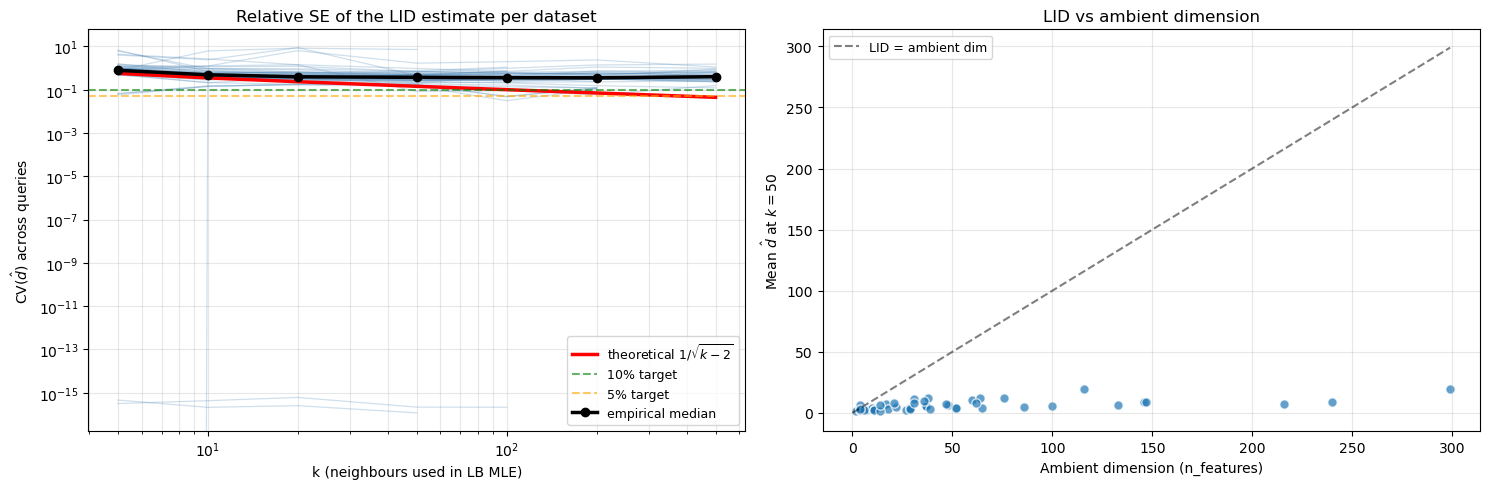

Per-dataset summary (sorted by CV at k=10, worst first):
                            dataset    n  n_feat  mean_lid_k=50  cv_at_k=10  cv_at_k=50  cv_at_k=200  k_for_20pct  k_for_10pct
    dataset_865_analcatdata_neavote  100       4           6.50       6.245       7.218          NaN          NaN          NaN
                   dataset_757_meta  528      65           4.13       2.654       0.084        0.059         50.0         50.0
      dataset_1014_analcatdata_dmft  797       7           2.26       2.440       0.453        0.435          NaN          NaN
               dataset_463_backache  180      31          11.03       1.263       0.959          NaN          NaN          NaN
                   dataset_1056_mc1 9466      38          12.24       1.246       1.696        2.393          NaN          NaN
                    dataset_38_sick 3772      52           3.97       1.164       0.693        0.530          NaN          NaN
                   dataset_1049_pc4 1458      37      

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: relative SE of LID vs k, per dataset, with theoretical line ────────
ax = axes[0]
for _, group in df_lid.groupby('dataset'):
    g = group.sort_values('k')
    ax.plot(g['k'], g['cv_lid'], color='steelblue', alpha=0.25, linewidth=0.9)

ks_th = np.array(K_GRID)
ax.plot(ks_th, 1.0 / np.sqrt(ks_th - 2), 'r-', linewidth=2.5,
        label=r'theoretical $1/\sqrt{k-2}$')
ax.axhline(0.10, color='green',  linestyle='--', alpha=0.6, label='10% target')
ax.axhline(0.05, color='orange', linestyle='--', alpha=0.6, label='5% target')

# Median across datasets at each k — shows the typical curve.
median_cv = df_lid.groupby('k')['cv_lid'].median()
ax.plot(median_cv.index, median_cv.values, 'k-', linewidth=2.5,
        marker='o', label='empirical median')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k (neighbours used in LB MLE)')
ax.set_ylabel(r'CV($\hat d$) across queries')
ax.set_title('Relative SE of the LID estimate per dataset')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# ── Right: mean LID at k=50 vs ambient dimension ─────────────────────────────
ax = axes[1]
df_at = df_lid[df_lid['k'] == 50]
ax.scatter(df_at['n_feat'], df_at['mean_lid'],
           s=45, alpha=0.7, edgecolors='white')
max_d = max(df_at['n_feat'].max(), df_at['mean_lid'].max())
ax.plot([0, max_d], [0, max_d], 'k--', alpha=0.5, label='LID = ambient dim')
ax.set_xlabel('Ambient dimension (n_features)')
ax.set_ylabel(r'Mean $\hat d$ at $k = 50$')
ax.set_title('LID vs ambient dimension')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Per-dataset summary table ────────────────────────────────────────────────
summary_rows = []
for ds_name, group in df_lid.groupby('dataset'):
    g = group.sort_values('k')
    below_10 = g[g['cv_lid'] <= 0.10]
    below_20 = g[g['cv_lid'] <= 0.20]
    summary_rows.append({
        'dataset':         ds_name,
        'n':               int(g['n'].iloc[0]),
        'n_feat':          int(g['n_feat'].iloc[0]),
        'mean_lid_k=50':   round(float(g[g['k']==50]['mean_lid'].iloc[0]), 2)
                            if 50 in g['k'].values else np.nan,
        'cv_at_k=10':      round(float(g[g['k']==10]['cv_lid'].iloc[0]), 3),
        'cv_at_k=50':      round(float(g[g['k']==50]['cv_lid'].iloc[0]), 3)
                            if 50 in g['k'].values else np.nan,
        'cv_at_k=200':     round(float(g[g['k']==200]['cv_lid'].iloc[0]), 3)
                            if 200 in g['k'].values else np.nan,
        'k_for_20pct':     int(below_20['k'].iloc[0]) if len(below_20) else np.nan,
        'k_for_10pct':     int(below_10['k'].iloc[0]) if len(below_10) else np.nan,
    })
summary_df = pd.DataFrame(summary_rows).sort_values('cv_at_k=10', ascending=False)

print(f"Per-dataset summary (sorted by CV at k=10, worst first):")
print(summary_df.to_string(index=False))
print()
n_tot = len(summary_df)
n_10  = summary_df['k_for_10pct'].notna().sum()
n_20  = summary_df['k_for_20pct'].notna().sum()
print(f'Median CV at k=10:  {df_lid[df_lid.k==10].cv_lid.median():.3f}')
print(f'Median CV at k=50:  {df_lid[df_lid.k==50].cv_lid.median():.3f}')
print(f'Median CV at k=200: {df_lid[df_lid.k==200].cv_lid.median():.3f}')
print(f'Reach ≤20% CV at any feasible k: {n_20}/{n_tot} datasets')
print(f'Reach ≤10% CV at any feasible k: {n_10}/{n_tot} datasets')

Multiplicative error in k_eff = (d_min/d_maj)^Δ
(rows = LID estimation error; columns = local distance ratio at k_probe)

LID error Δ  ratio=1.05  ratio=1.1  ratio=1.2  ratio=1.5  ratio=2.0
       ±0.5        1.02       1.05       1.10       1.22       1.41
       ±1.0        1.05       1.10       1.20       1.50       2.00
       ±2.0        1.10       1.21       1.44       2.25       4.00
       ±5.0        1.28       1.61       2.49       7.59      32.00
      ±10.0        1.63       2.59       6.19      57.67    1024.00


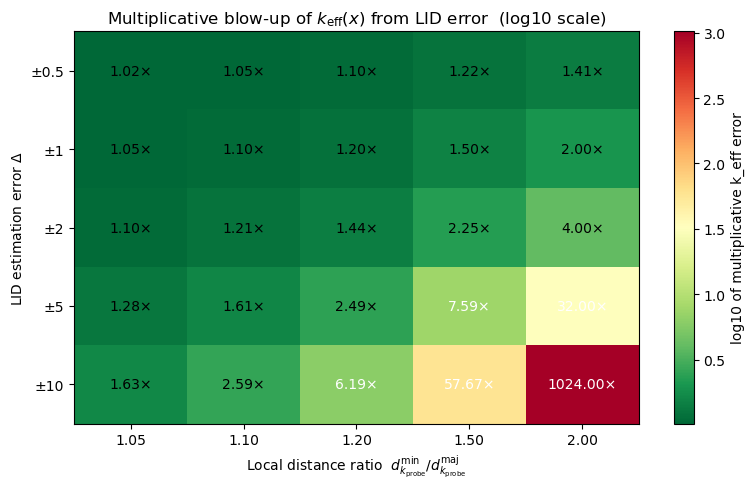

In [3]:
# ── Sensitivity: how badly does an LID error blow up k_eff? ──────────────────
# k_eff_est / k_eff_true = (d_min / d_maj) ** Delta_d

ratios       = [1.05, 1.10, 1.20, 1.50, 2.00]
lid_errors   = [0.5, 1.0, 2.0, 5.0, 10.0]

rows = []
for delta in lid_errors:
    rows.append({'LID error Δ': f'±{delta}', **{f'ratio={r}': round(r ** delta, 2)
                                                  for r in ratios}})
sens_df = pd.DataFrame(rows)

print('Multiplicative error in k_eff = (d_min/d_maj)^Δ')
print('(rows = LID estimation error; columns = local distance ratio at k_probe)')
print()
print(sens_df.to_string(index=False))

# Heatmap visualisation
fig, ax = plt.subplots(figsize=(8, 5))
Z = np.array([[r ** delta for r in ratios] for delta in lid_errors])
im = ax.imshow(np.log10(Z), cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(ratios)));     ax.set_xticklabels([f'{r:.2f}' for r in ratios])
ax.set_yticks(range(len(lid_errors))); ax.set_yticklabels([f'±{d:g}' for d in lid_errors])
ax.set_xlabel(r'Local distance ratio  $d_{k_\text{probe}}^\text{min} / d_{k_\text{probe}}^\text{maj}$')
ax.set_ylabel(r'LID estimation error $\Delta$')
ax.set_title(r'Multiplicative blow-up of $k_\text{eff}(x)$ from LID error  (log10 scale)')
for i in range(len(lid_errors)):
    for j in range(len(ratios)):
        v = Z[i, j]
        ax.text(j, i, f'{v:.2f}×', ha='center', va='center',
                fontsize=10, color='white' if np.log10(v) > 0.7 else 'black')
fig.colorbar(im, ax=ax, label='log10 of multiplicative k_eff error')
plt.tight_layout()
plt.show()

### 12.4 Reading the results

Three things to look for in the figures and tables above.

**(a) Does the empirical CV match the theoretical $1/\sqrt{k-2}$?** If the empirical median curve sits *above* the theoretical line at large $k$, the gap is genuine LID heterogeneity within the dataset — pumping $k$ further will not close it. If the empirical curve tracks the theoretical line, the estimator noise dominates and a larger $k$ does help.

**(b) Per-dataset $k$ to reach 10% / 20% relative precision.** The summary table tells us the dataset-by-dataset budget. The interesting cases are the datasets where even $k = 200$ doesn't get below 20% — those are the ones where the local-density rank correction in §11 is fundamentally noisy regardless of how generous we are with $k$.

**(c) Sensitivity heatmap.** The right-hand cells (large distance ratio, large LID error) blow up by orders of magnitude. The left-hand cells (small distance ratio, small LID error) stay near $1\times$. Where do our typical queries fall? At the v3 decision boundary distances are close to parity, so distance ratios at $k_\text{probe}$ are usually $\leq 1.2$ — meaning LID errors of $\pm 1$ to $\pm 2$ are tolerable. But under severe imbalance (large $r$ → large reference ratio $r^{1/d}$) we land in the dangerous region.

### 12.5 What this means for the §11 redesign

Three implications:

1. **$k_\text{probe}$ for the density ratio should be $\sim 50$, not 10.** $k = 10$ gives $\sim 35\%$ relative SE on the LID estimate; $k = 50$ brings it to $\sim 14\%$. Datasets too small to support $k_\text{probe} = 50$ should fall back to $k_\text{probe} = \min(50, N/4)$.
2. **Clamping is not optional.** The sensitivity analysis confirms it: even modest LID errors blow up $k_\text{eff}$ in the high-imbalance / low-ambient-dim corner. Clamp to $k_\text{eff}(x) \in [\lceil r^{0.25} \rceil, \lceil r^{1.5} \rceil]$ (the dimension-aware range from §11.6) — this caps the worst case at $\sim 4\times$ even when the raw formula tries to multiply by 100×.
3. **Use ambient $n_\text{features}$ as a cap on $\hat d$.** Many datasets show LID $\ll n_\text{features}$ in the right-hand scatter — that is the manifold story, and using LID is correct there. But when LID estimation is unstable for a particular query, capping at $n_\text{features}$ at least keeps the exponent finite.

---

## 13. Modification E (Rank-Native): Local Class Odds for Per-Query $k_\text{eff}$

### 13.1 Where §11 leaks the dimension back in

The §11 derivation is dimension-free up to the moment we plug in an estimator for $p(x \mid \text{maj}) / p(x \mid \text{min})$. The k-NN density estimator turns distances back into densities through $1/d_k^d$ — which is exactly where $d$ re-enters. The §12 numerical analysis showed that $\hat d$ has $\geq 35\%$ relative SE at $k = 10$ and barely improves with more neighbours (because dataset heterogeneity dominates). Combined with the $d$-th-power amplification in $(d_\text{min}/d_\text{maj})^d$, the §11 formula is structurally fragile.

v3's elegance was that the $d$-th power on each side cancels *exactly before estimation*. The whole point of the rank formulation was to get a dimension-free correction. §11 broke that. We want it back.

### 13.2 The fix: estimate the ratio without going through density

Use Bayes' rule on the *posterior* directly. The local class proportion in the $K$ nearest mixed-class neighbours of $x$ is an estimator of the posterior $\pi(c \mid x) = P(c \mid x)$:

$$\hat\pi(c \mid x) \;=\; \frac{\#\{c\text{-class points in }K\text{-NN}(x)\}}{K}.$$

Bayes' rule rearranged gives

$$\frac{p(x \mid \text{maj})}{p(x \mid \text{min})} \;=\; \frac{P(\text{maj} \mid x) / P(\text{min} \mid x)}{P(\text{maj}) / P(\text{min})} \;\approx\; \frac{\hat\pi(\text{maj} \mid x) / \hat\pi(\text{min} \mid x)}{r}.$$

Substitute into the §11 master formula $k_\text{eff} = r \cdot p(\text{maj}) / p(\text{min})$. The global $r$ cancels:

$$\boxed{\,k_\text{eff}(x) \;=\; \frac{\hat\pi(\text{maj} \mid x)}{\hat\pi(\text{min} \mid x)} \;=\; \frac{\#\{\text{maj in }K\text{-NN}(x)\}}{\#\{\text{min in }K\text{-NN}(x)\}}\,}$$

It is a counting operation. No $d$, no volume term $V_d$, no $(d_\text{min}/d_\text{maj})^d$. The rank correction is once again derived without ever committing to a value of the intrinsic dimensionality.

### 13.3 Sanity check: recovers v3 in the homogeneous case

Under homogeneous local density at $x$, the $K$ nearest neighbours of $x$ are class-distributed in proportion to the global ratio:

$$\#\{\text{maj in }K\text{-NN}(x)\} \;\approx\; K \cdot \frac{r}{r+1}, \qquad \#\{\text{min in }K\text{-NN}(x)\} \;\approx\; K \cdot \frac{1}{r+1}.$$

$$\Longrightarrow\quad k_\text{eff}(x) \;\approx\; r.$$

Recovers v3 in expectation. The proposed correction only differs from v3 in regions where the local class proportion deviates from the global one — exactly the F1/F2 failure modes of v3.

### 13.4 Off-uniform behaviour

**Locally minority-rich** (dense minority cluster). $\#\{\text{min in }K\text{-NN}\}$ is locally large, so $k_\text{eff}(x) < r$. The rank correction is mild — the algorithm doesn't over-reach to predict minority where minority points already cluster naturally. ✓

**Locally minority-sparse** (majority-dominated zone with one stray minority). $\#\{\text{min in }K\text{-NN}\}$ is small, so $k_\text{eff}(x) > r$. Stronger correction — gives the minority class a chance even in deeply majority-skewed regions. ✓

**Pure majority neighbourhood.** $\#\{\text{min in }K\text{-NN}\} = 0$, so $k_\text{eff}(x)$ is undefined. Resolved by Laplace smoothing $(+1/+1)$:

$$k_\text{eff}(x) \;=\; \frac{\#\{\text{maj}\} + 1}{\#\{\text{min}\} + 1}.$$

With $K = 10$ this gives $k_\text{eff}(x) \in [\tfrac{1}{11},\, 11]$ automatically — no explicit clamp needed.

### 13.5 The voting framework (unchanged from v3)

Once $k_\text{eff}(x)$ is fixed for the query, the vote is exactly v3's binary comparison:

$$\text{vote}_i(x) \;=\; \begin{cases} +1 & d_i^\text{min}(x) < d_{i \cdot k_\text{eff}(x)}^\text{maj}(x) \\ 0 & \text{otherwise} \end{cases}$$

for $i = 1, \ldots, n_\text{votes}$, aggregated as a binary fraction. Predict minority iff that fraction $> 0.5$. The aggregation is identical to v3 — only $k_\text{eff}$ changed from a global constant $r$ to a per-query function of the local class odds.

### 13.6 Why this beats §11 by construction

§11 vs §13 differ only in how they estimate $p(\text{maj})/p(\text{min})$:

| | §11 (current Mod E) | §13 (proposed) |
| :--- | :--- | :--- |
| Density-ratio estimator | $\frac{N_\text{min}}{N_\text{maj}} \cdot \left(\frac{d_{k}^\text{min}}{d_{k}^\text{maj}}\right)^{\!d}$ | $\frac{1}{r} \cdot \frac{\#\{\text{maj in }K\text{-NN}\}}{\#\{\text{min in }K\text{-NN}\}}$ |
| Requires $\hat d$? | yes | no |
| Sensitive to LID error? | yes (multiplicatively, see §12.6) | no |
| Behaviour at high imbalance / low ambient $d$ | catastrophic (sensitivity heatmap) | bounded by $K+1$ |
| Recovers v3 under uniform density | yes (in expectation) | yes (in expectation) |

The §13 estimator inherits whatever variance comes from counting $K$ points (multinomial sampling), but does **not** inherit the $d$-th-power amplification that makes §11 fragile.

### 13.7 The single-line patch to v3

Implementation-wise, this is a one-method change to `KNNFairRank`:

- v3 computes `k_eff = round(self._r)` once at fit time.
- §13 computes `k_eff(x)` per query: count `K`-NN class membership, take the smoothed odds.

Everything else — the per-class distance fetch, the $n_\text{votes}$ ensemble, the binary vote, the aggregation, the `predict_proba` mapping — is inherited unchanged.

### 13.8 Open design choices

1. **$K$ for the local-odds count.** Default suggestion: $K = k_\text{min,eff} = 10$ (matches what we already fetch). Smaller $K$ is more local but the odds become discrete (0/5, 1/5, ..., 5/5) and noisy. Larger $K$ smooths but loses locality. Inner-CV tuning over $K \in \{5, 10, 20, 50\}$ is cheap and would be analogous to Mod C tuning $\alpha$.
2. **Smoothing strength.** Laplace $(+1/+1)$ is canonical. Larger pseudo-counts shrink $k_\text{eff}(x)$ toward $1$ (no correction), smaller toward the raw odds. Probably not worth tuning.
3. **Clamping.** With Laplace smoothing the ratio is naturally bounded in $[1/(K+1),\, K+1]$. No explicit clamp needed unless we want to also bound it relative to $r$ (e.g., disallow $k_\text{eff}(x) > 2r$ for stability under severe imbalance — but the natural cap from $K$ is probably enough).

---

## 14. Per-Class Eigenvalue Effective Dimension for Global α Selection

### 14.1 Context and motivation

`KNNFairRankCV` selects the correction exponent α ∈ {0.25, 0.5, 0.75, 1.0} via inner
stratified cross-validation. This works well empirically (best G-mean rank in the benchmark)
but has conceptual problems: it is sensitive to the inner-CV scoring metric, noisy on small
minority folds, and the metric choice is itself a meta-hyperparameter we end up tuning by
looking at the benchmark.

We tried replacing inner CV with an analytical signal derived from local intrinsic
dimensionality (LID):

- **Mean LID → α = 1/d̂**: wrong direction, mostly clamped.
- **LID coefficient of variation → α = 1 − scale·CV_LID**: better direction but
  insufficient range; CV_LID values for datasets needing α=1.0 and α=0.25 overlap.
- **α = CV_LID/2**: directionally correct for low-α datasets, but can't reach 1.0
  for the majority of datasets.

The fundamental problem: all LID-based signals measure *dimensionality* or *geometric
spread*, but the right α is about *decision boundary strictness* — how aggressively to
predict minority. These are related but do not map cleanly onto each other.

### 14.2 New idea: per-class eigenvalue comparison

The insight from the FairRank derivation: the correction k_eff = r assumes that minority
and majority have **the same local covariance structure** (homogeneous Poisson). When this
holds, the global r correction is exact. When minority is *more compact* than majority —
living in a lower-dimensional subspace, with more concentrated eigenvalue spectra — the
Poisson assumption is violated in a specific, measurable way.

The proposed signal is not global dimensionality but the **ratio of effective dimensions
between the two classes**:

    d_eff_min = effective_dim(X_min, threshold=0.95)   # fit-time, stable
    d_eff_maj = effective_dim(X_maj, threshold=0.95)   # fit-time, stable
    dim_ratio  = d_eff_min / d_eff_maj                 # ∈ (0, ∞)

where `effective_dim` uses the PCA eigenvalue spectrum exactly as in `KNNAdaptiveEigen`
(§ `_effective_dim`): number of components explaining ≥ 95% of variance in the class
point cloud.

**Interpretation:**

| dim_ratio | Meaning | Expected α |
|---|---|---|
| ≈ 1 | Classes have similar local structure → Poisson holds | 1.0 |
| < 1 | Minority more compact than majority → over-correction risk | < 1.0 |
| > 1 | Minority more spread than majority → under-correction risk | could exceed 1.0, clamp to 1.0 |

**Proposed formula (starting point):**

    α = clip(dim_ratio, alpha_min, 1.0)

When dim_ratio ≈ 1: α ≈ 1.0 (full correction). When minority is half the effective
dimension of majority (dim_ratio = 0.5): α ≈ 0.5. This is a one-to-one mapping with
a natural interpretation, no scale parameter to calibrate.

### 14.3 Why this is different from mean LID

Mean LID tells us the global dimensionality of the feature space — d cancels in the
FairRank derivation, so it cannot inform α.

The dim_ratio compares *the relative geometric compactness of the two classes*. This is
a **class-discriminative** signal. The Poisson uniform assumption is about both classes
sharing the same local density scale, so the right diagnostic is a *comparison between
classes*, not a property of the space itself.

### 14.4 Implementation plan

New class `KNNFairRankEigenCV` (or rename `KNNFairRankLID` to this):

1. Inherit from `KNNFairRank`.
2. In `fit()`:
   - Separate `X_min = X[y == minority_class]`, `X_maj = X[y == majority_class]`.
   - Compute `d_eff_min = _effective_dim(X_min)` and `d_eff_maj = _effective_dim(X_maj)`.
   - Set `α = clip(d_eff_min / d_eff_maj, alpha_min=0.0, alpha_max=1.0)`.
3. `_vote_fraction()` is identical to `KNNFairRankCV._vote_fraction()` — uses `r^α`.

The `_effective_dim` method already exists in `KNNAdaptiveEigen` and can be reused
directly (static, no predict-time calls needed).

**No inner CV. No scoring metric. No hyperparameter beyond the PCA threshold (0.95).**

### 14.5 Key open questions

1. **Does dim_ratio actually predict the CV-selected α?** The LID experiments showed
   that geometric signals don't always correlate with the right α. This is a better-motivated
   signal but must be validated empirically on the 49-dataset benchmark.
2. **Should we compute effective dim on the full class point cloud or a subsample?**
   For large datasets, PCA on all N_maj points is O(N_maj · d²). A subsample of 500
   points is probably sufficient and much cheaper.
3. **Should eigenvalue threshold be 0.95 or tuned?** The threshold controls how many
   components count as "significant". A higher threshold (0.99) gives larger d_eff;
   lower (0.90) gives smaller. Probably insensitive in the range 0.90–0.99.
4. **What happens with very small minority classes?** If N_min < d_features,
   `_effective_dim(X_min)` is unreliable (covariance matrix is rank-deficient).
   Fallback: if N_min < 2·d_features, set α = 1.0 (full correction, no evidence to deviate).
5. **Interaction with the ensemble**: could the same dim_ratio be used to weight
   votes differently across α values in `KNNFairRankEnsemble`?

### 14.6 Why this might still not work

The same fundamental tension applies: α is a decision boundary regularization parameter
(found by CV because CV directly optimizes prediction quality), while dim_ratio is a
geometric property of the training distribution. They may not correlate because:

- A dataset can have dim_ratio ≈ 1 but still benefit from α < 1 due to class overlap,
  noise, or boundary geometry that eigenvalues don't capture.
- Conversely, dim_ratio < 1 might not require reduced correction if the minority compactness
  is precisely what makes them easy to classify.

This is worth implementing and benchmarking before committing to it. If dim_ratio does
not predict α better than CV selects it, the right conclusion is that no fit-time
geometric signal can replace CV, and the effort should go elsewhere (topology-aware
per-query adaptation, or improving the CV approach itself).

---

## 15. Shared Intrinsic Dimensionality — Breaking the Circular Problem in Topology-Aware FairRank

### 15.1 The circular problem (recap)

§11 proposed a topology-aware per-query correction:

$$k_\text{eff}(x) = \frac{\hat\lambda_\text{maj}(x)}{\hat\lambda_\text{min}(x)}$$

The tool for estimating local density is persistent homology (PH). But minority topology estimation hits a wall: the Niyogi-Smale-Weinberger (NSW) bound says reliable topology detection requires

$$N_\text{min} \;\geq\; C \cdot \frac{1}{\tau^d} \log \frac{1}{\delta}$$

where $d$ is the intrinsic dimension and $\tau$ is the manifold reach (minimum radius of curvature). Under severe class imbalance $N_\text{min}$ is small, so we need $d$ and $\tau$ to compute the confidence $p_\text{topo}$ — but estimating them reliably also requires many points. The circularity: *to know whether minority topology is trustworthy, we need to characterise the minority manifold, which requires more minority points than we have.*

### 15.2 The claim: both classes share the same intrinsic dimensionality

**Claim:** $d_\text{eff}^\text{min} \approx d_\text{eff}^\text{maj}$, where $d_\text{eff}$ is the number of PCA components explaining ≥ 95% of within-class variance.

**Why this should hold.** Both classes are drawn from the same $d$-dimensional feature space. Each feature measures a real-world quantity whose variation is driven by underlying independent causal factors. Those factors are properties of the *domain*, not the class label. A healthy and a sick person both have blood pressure driven by the same biological factors (age, stress, genetics); the class label determines *which region* of causal space they occupy, not *how many* causal dimensions that space has.

More formally: both $P_\text{maj}$ and $P_\text{min}$ are conditionals of the same joint $P(x, y)$. The effective dimensionality of $P(x)$ — set by feature correlations in the data-generating process — is inherited by both conditionals $P(x \mid y)$. Unless one class collapses onto a strict lower-dimensional subspace (degenerate case), both share the same $d_\text{eff}$.

**What is NOT shared:** absolute density. $\lambda_\text{maj}(x) \gg \lambda_\text{min}(x)$ everywhere by definition of imbalance. The dimension determines the *rate* at which local density grows with radius ($\lambda \propto \epsilon^{d_\text{eff}}$); the constant in front is what differs between classes.

### 15.3 How this breaks the circularity

The NSW bound needs $d$ and $\tau$.

**For $d$:** Estimate $\hat d_\text{maj}$ from the majority class — many points, reliable PCA. Transfer to minority via the shared-dimension assumption. *This is the key step that the circularity blocked.*

**For $\tau$ (reach):** Reach is a geometric property of the manifold, not a density property. It does not require topology to estimate. A usable lower bound is:

$$\hat\tau_\text{min} \;\geq\; \frac{\min_{i \neq j} \|x_i^\text{min} - x_j^\text{min}\|}{2}$$

computable from raw coordinates with even 10 points. This gives a valid confidence interval for $p_\text{topo}$ without any topological computation on the minority cloud.

**Result:** $p_\text{topo}(N_\text{min},\, \hat d_\text{maj},\, \hat\tau_\text{min})$ is now computable without touching minority topology. The confidence-weighted interpolation from §11.4 becomes:

$$k_\text{eff}^\text{weighted}(x) = p_\text{topo} \cdot k_\text{eff}^\text{topo}(x) + (1 - p_\text{topo}) \cdot r$$

When $N_\text{min}$ is small (high imbalance), $p_\text{topo} \to 0$ and the algorithm recovers FairRank. When $N_\text{min}$ is large enough to satisfy the NSW bound, $p_\text{topo} \to 1$ and the full local correction is used.

### 15.4 An alternative that avoids minority topology entirely

The shared $d_\text{eff}$ also justifies a structurally cleaner approach:

1. Run PH on the **joint** point cloud (all $N = N_\text{maj} + N_\text{min}$ points). Reliable: $N$ is large.
2. Use H0 persistence to partition training space into topological regions $\{R_1, \ldots, R_m\}$.
3. Per region: $k_{\text{eff},j} = N_\text{maj}(R_j) / N_\text{min}(R_j)$ — local imbalance ratio, not global $r$.
4. At predict time: assign $x$ to its nearest region, return $k_{\text{eff},j}$.

The shared $d_\text{eff}$ justifies step 2: the joint manifold topology is a valid scaffold for *both* classes because they live on the same effective manifold. Without it, a partition defined by joint geometry might not be meaningful for class-conditional densities. With it, the partition is fair: regions where minority is locally dense get a smaller $k_\text{eff}$; regions where minority is sparse get a larger one.

Graceful degradation: if minority is spread uniformly across regions, all $k_{\text{eff},j} \approx r$ and the algorithm recovers standard FairRank exactly.

### 15.5 What could still go wrong

- **Reach doesn't transfer cleanly.** Minority might have smaller reach than majority (tight minority cluster = high curvature = small $\tau$). The minimum-pairwise-distance estimator avoids transferring $\tau$ by using minority coordinates directly, but it gives a lower bound, making $p_\text{topo}$ conservative.
- **Degenerate minority.** If $N_\text{min} < d_\text{features}$, minority covariance is rank-deficient. Fallback: use $\hat d_\text{maj}$ directly and set $p_\text{topo} = 0$ until $N_\text{min}$ is large enough to pass the NSW bound.
- **The assumption fails on some datasets.** Classes with genuinely different dimensionalities (majority fills a 5D region, minority lies on a 1D curve) would break the transfer. The empirical tests below check how common this is across the benchmark.

### 15.6 Empirical question

Does $d_\text{eff}^\text{min} \approx d_\text{eff}^\text{maj}$ hold across the benchmark?

**Test 1 — PCA effective dimension:** compute $d_\text{eff}$ (95% variance threshold) per class. Scatter $d_\text{eff}^\text{min}$ vs $d_\text{eff}^\text{maj}$; plot distribution of $d_\text{eff}^\text{min} / d_\text{eff}^\text{maj}$.

**Test 2 — NN distance log-log slope:** the slope of $\log(\bar d_k)$ vs $\log k$ estimates $1/d_\text{eff}$ without PCA. Compare slopes per class — this handles non-linear manifolds that PCA misses.

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Datasets with estimable minority d_eff: 36 / 49

dim_ratio = d_eff_min / d_eff_maj
  median:  0.778
  mean:    0.770
  std:     0.227
  fraction in [0.5,  1.5]:  91.7%
  fraction in [0.75, 1.25]: 55.6%


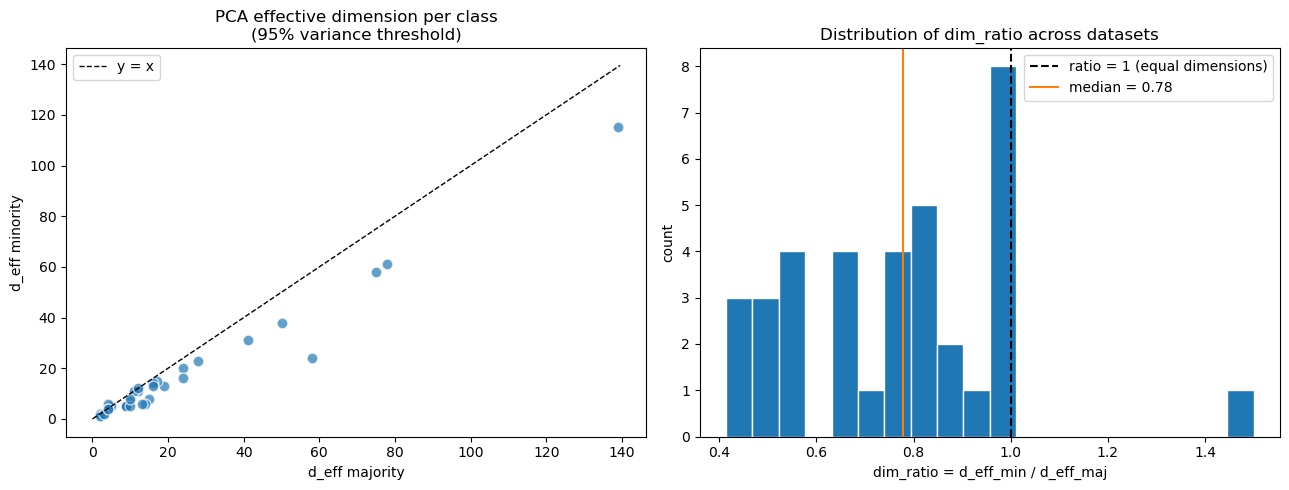


Datasets with largest dimension gap (dim_ratio furthest from 1.0):
                           dataset         ir  n_min  n_feat  d_eff_maj  d_eff_min  dim_ratio
         dataset_971_mfeat-fourier   9.000000    200      76       58.0       24.0   0.413793
                  dataset_1056_mc1 138.205882     68      38       14.0        6.0   0.428571
 dataset_875_analcatdata_chlamydia   4.263158     19      17       13.0        6.0   0.461538
          dataset_1021_page-blocks   8.773214    560      10        4.0        6.0   1.500000
     dataset_951_arsenic-male-lung  42.000000     13       4        2.0        1.0   0.500000
               dataset_958_segment   6.000000    330      18       10.0        5.0   0.500000
   dataset_865_analcatdata_neavote  13.285714      7       4        2.0        1.0   0.500000
                  dataset_1049_pc4   7.191011    178      37       15.0        8.0   0.533333
    dataset_765_analcatdata_apnea2   6.421875     64      11        9.0        5.0   0

In [4]:
# Test 1: PCA effective dimension per class across all datasets
# Self-contained — no cells above need to be run first.
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features

THRESHOLD = 0.95

def pca_effective_dim(X, threshold=THRESHOLD):
    if X.shape[0] < 2:
        return 1.0
    centred = X - X.mean(axis=0)
    cov = centred.T @ centred / (X.shape[0] - 1)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(eigvals)[::-1]
    eigvals = np.maximum(eigvals, 0.0)
    total = eigvals.sum()
    if total == 0:
        return 1.0
    cumvar = np.cumsum(eigvals) / total
    return float(np.searchsorted(cumvar, threshold) + 1)

datasets = load_all_datasets()

rows = []
for ds in datasets:
    X, y = ds.X, binarise_labels(ds.y)
    X = remove_constant_features(X)
    X = StandardScaler().fit_transform(X)
    n_min = int(y.sum())
    n_feat = X.shape[1]
    d_maj = pca_effective_dim(X[y == 0])
    d_min = pca_effective_dim(X[y == 1]) if n_min >= max(2, n_feat) else float("nan")
    rows.append({
        "dataset": ds.name,
        "n_min": n_min,
        "ir": int((1 - y).sum()) / max(n_min, 1),
        "n_feat": n_feat,
        "d_eff_maj": d_maj,
        "d_eff_min": d_min,
        "dim_ratio": d_min / d_maj if d_min == d_min else float("nan"),
    })

dim_df = pd.DataFrame(rows)
valid = dim_df.dropna(subset=["d_eff_min"])

print(f"Datasets with estimable minority d_eff: {len(valid)} / {len(dim_df)}")
print(f"\ndim_ratio = d_eff_min / d_eff_maj")
print(f"  median:  {valid['dim_ratio'].median():.3f}")
print(f"  mean:    {valid['dim_ratio'].mean():.3f}")
print(f"  std:     {valid['dim_ratio'].std():.3f}")
print(f"  fraction in [0.5,  1.5]:  {((valid['dim_ratio'] >= 0.5)  & (valid['dim_ratio'] <= 1.5)).mean():.1%}")
print(f"  fraction in [0.75, 1.25]: {((valid['dim_ratio'] >= 0.75) & (valid['dim_ratio'] <= 1.25)).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(valid["d_eff_maj"], valid["d_eff_min"], alpha=0.7, edgecolors="white", s=60)
lim = max(valid["d_eff_maj"].max(), valid["d_eff_min"].max()) + 0.5
ax.plot([0, lim], [0, lim], "k--", lw=1, label="y = x")
ax.set_xlabel("d_eff majority")
ax.set_ylabel("d_eff minority")
ax.set_title("PCA effective dimension per class\n(95% variance threshold)")
ax.legend()

ax = axes[1]
ax.hist(valid["dim_ratio"], bins=20, edgecolor="white")
ax.axvline(1.0, color="k", ls="--", lw=1.5, label="ratio = 1 (equal dimensions)")
ax.axvline(valid["dim_ratio"].median(), color="tab:orange", ls="-", lw=1.5,
           label=f"median = {valid['dim_ratio'].median():.2f}")
ax.set_xlabel("dim_ratio = d_eff_min / d_eff_maj")
ax.set_ylabel("count")
ax.set_title("Distribution of dim_ratio across datasets")
ax.legend()
plt.tight_layout()
plt.show()

print("\nDatasets with largest dimension gap (dim_ratio furthest from 1.0):")
print(valid[["dataset", "ir", "n_min", "n_feat", "d_eff_maj", "d_eff_min", "dim_ratio"]]
      .sort_values("dim_ratio", key=lambda s: (s - 1).abs(), ascending=False)
      .head(15).to_string(index=False))


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Datasets with estimable minority slope: 49 / 49

slope_ratio = slope_min / slope_maj  (1.0 = same intrinsic dimension)
  median:  1.049
  mean:    1.605
  std:     3.110
  fraction in [0.7, 1.3]: 59.2%


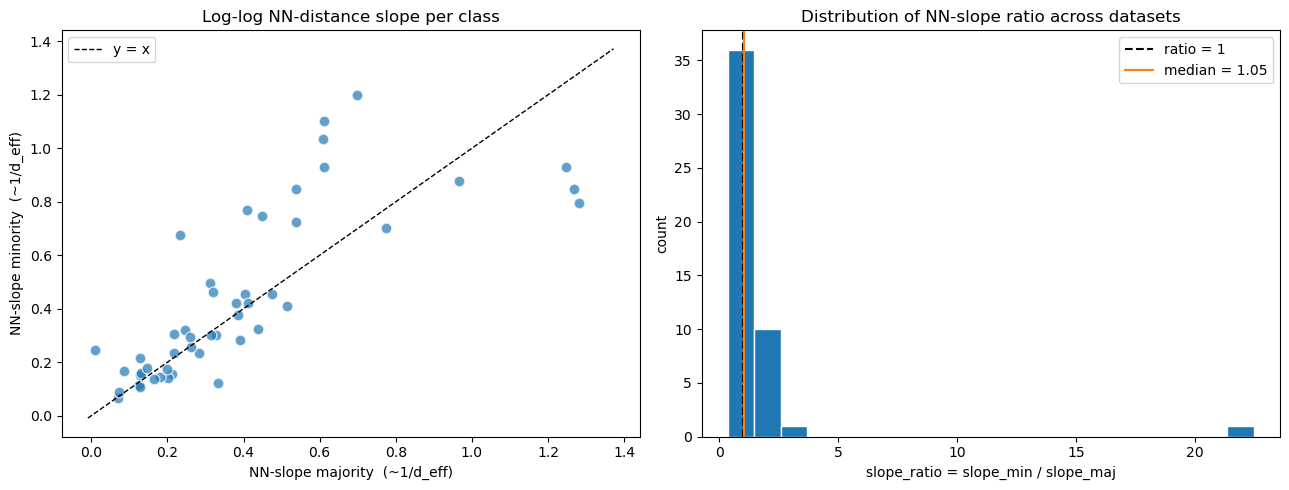


Correlation between PCA dim_ratio and NN-slope ratio: 0.131
(High = both tests agree on which datasets break the shared-dimension assumption)


In [5]:
# Test 2: NN-distance log-log slope as independent intrinsic dimension estimate
# Self-contained — no cells above need to be run first.
# Slope of log(mean k-NN distance) vs log(k) ≈ 1/d_eff.
# If both classes share the same slope they share the same intrinsic dimension.
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features

K_MAX = 20
K_MIN = 2

def nn_slope(X, k_max=K_MAX, k_min=K_MIN):
    n = X.shape[0]
    k_max = min(k_max, n - 1)
    if k_max < k_min:
        return float("nan")
    nbrs = NearestNeighbors(n_neighbors=k_max).fit(X)
    dists, _ = nbrs.kneighbors(X)
    ks = np.arange(k_min, k_max + 1)
    mean_dists = dists[:, k_min - 1: k_max].mean(axis=0)
    if np.any(mean_dists <= 0):
        return float("nan")
    slope, _ = np.polyfit(np.log(ks), np.log(mean_dists), 1)
    return slope  # ≈ 1/d_eff

def pca_effective_dim(X, threshold=0.95):
    if X.shape[0] < 2:
        return 1.0
    centred = X - X.mean(axis=0)
    cov = centred.T @ centred / (X.shape[0] - 1)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(eigvals)[::-1]
    eigvals = np.maximum(eigvals, 0.0)
    total = eigvals.sum()
    if total == 0:
        return 1.0
    cumvar = np.cumsum(eigvals) / total
    return float(np.searchsorted(cumvar, threshold) + 1)

datasets = load_all_datasets()

rows = []
for ds in datasets:
    X, y = ds.X, binarise_labels(ds.y)
    X = remove_constant_features(X)
    X = StandardScaler().fit_transform(X)
    n_min = int(y.sum())
    n_feat = X.shape[1]

    s_maj = nn_slope(X[y == 0])
    s_min = nn_slope(X[y == 1]) if n_min >= K_MIN + 1 else float("nan")
    d_maj = pca_effective_dim(X[y == 0])
    d_min = pca_effective_dim(X[y == 1]) if n_min >= max(2, n_feat) else float("nan")

    rows.append({
        "dataset": ds.name,
        "ir": int((1 - y).sum()) / max(n_min, 1),
        "n_min": n_min,
        "slope_maj": s_maj,
        "slope_min": s_min,
        "slope_ratio": s_min / s_maj if (s_min == s_min and s_maj != 0) else float("nan"),
        "dim_ratio": d_min / d_maj if d_min == d_min else float("nan"),
    })

df = pd.DataFrame(rows)
valid_s = df.dropna(subset=["slope_min"])

print(f"Datasets with estimable minority slope: {len(valid_s)} / {len(df)}")
print(f"\nslope_ratio = slope_min / slope_maj  (1.0 = same intrinsic dimension)")
print(f"  median:  {valid_s['slope_ratio'].median():.3f}")
print(f"  mean:    {valid_s['slope_ratio'].mean():.3f}")
print(f"  std:     {valid_s['slope_ratio'].std():.3f}")
print(f"  fraction in [0.7, 1.3]: {((valid_s['slope_ratio'] >= 0.7) & (valid_s['slope_ratio'] <= 1.3)).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(valid_s["slope_maj"], valid_s["slope_min"], alpha=0.7, edgecolors="white", s=60)
lo = min(valid_s["slope_maj"].min(), valid_s["slope_min"].min()) - 0.02
hi = max(valid_s["slope_maj"].max(), valid_s["slope_min"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax.set_xlabel("NN-slope majority  (~1/d_eff)")
ax.set_ylabel("NN-slope minority  (~1/d_eff)")
ax.set_title("Log-log NN-distance slope per class")
ax.legend()

ax = axes[1]
ax.hist(valid_s["slope_ratio"], bins=20, edgecolor="white")
ax.axvline(1.0, color="k", ls="--", lw=1.5, label="ratio = 1")
ax.axvline(valid_s["slope_ratio"].median(), color="tab:orange", ls="-", lw=1.5,
           label=f"median = {valid_s['slope_ratio'].median():.2f}")
ax.set_xlabel("slope_ratio = slope_min / slope_maj")
ax.set_ylabel("count")
ax.set_title("Distribution of NN-slope ratio across datasets")
ax.legend()
plt.tight_layout()
plt.show()

# Cross-check: do both estimators flag the same outlier datasets?
merged = df.dropna(subset=["slope_ratio", "dim_ratio"])
corr = merged["dim_ratio"].corr(merged["slope_ratio"])
print(f"\nCorrelation between PCA dim_ratio and NN-slope ratio: {corr:.3f}")
print("(High = both tests agree on which datasets break the shared-dimension assumption)")


### 15.7 Reading the results

**What supports the claim ($d_\text{eff}^\text{min} \approx d_\text{eff}^\text{maj}$):**
- `dim_ratio` and `slope_ratio` distributions concentrated around 1.0
- Both tests agree on which datasets are outliers (high cross-test correlation)

**Even if imperfect, what the dimension transfer enables:**
Using $\hat d_\text{maj}$ as a prior gives a conservative $p_\text{topo}$ — an overestimated $d$ makes the NSW bound harder to satisfy, which lowers $p_\text{topo}$, which pushes weight toward FairRank. The algorithm degrades safely; it never becomes *worse* than FairRank.

**What would invalidate the approach:**
`dim_ratio` systematically much less than 1 across most datasets — minority genuinely in a lower-dimensional subspace. The algorithm would still be safe (falls back to FairRank) but would rarely exploit topology at all.

**Next step if results are favourable:** implement `KNNFairRankTopoJoint` using the joint-cloud approach (§15.4) — run PH once at fit time on all $N$ points, store per-region $k_\text{eff}$, use at predict time. No minority-only PH ever required.

### 15.8 Deriving the expected dim_ratio from Marchenko-Pastur

#### The setup

Suppose both classes have the **same true covariance** $\Sigma = I_d$ (identity — all features independent, equal variance). The minority class has $N_\text{min}$ samples and the majority has $N_\text{maj}$ samples. We want to know: what PCA dim_ratio do we *expect to observe* purely because of the sample size difference, with no structural difference at all?

#### The Marchenko-Pastur distribution

When you compute a sample covariance matrix from $N$ i.i.d. samples in $d$ dimensions, the $d$ sample eigenvalues are **not** all equal to 1 (the true value). They are spread around 1 according to the **Marchenko-Pastur distribution** with parameter:

$$c = \frac{d}{N}$$

The density is:

$$\rho_c(\lambda) = \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{2\pi c\, \lambda}, \qquad \lambda \in [\lambda_-, \lambda_+]$$

where the support boundaries are:

$$\lambda_\pm = \left(1 \pm \sqrt{c}\right)^2$$

When $c$ is small (many samples relative to features): $\lambda_- \approx \lambda_+ \approx 1$ — eigenvalues cluster tightly around the true value. When $c$ is large (few samples): the distribution spreads wide.

#### Why fewer samples gives lower $d_\text{eff}$

PCA effective dimension counts how many eigenvalues (sorted descending) sum to 95% of total sample variance.

- When $c \approx 0$: all eigenvalues $\approx 1$, each explains $1/d$ of variance. You need $0.95 \times d$ components. So $d_\text{eff} \approx 0.95d$.
- When $c > 0$: the eigenvalue distribution is **right-skewed**. The top few eigenvalues are inflated above 1 and carry disproportionate variance. You reach 95% sooner. So $d_\text{eff} < 0.95d$.

The larger $c$ (fewer samples), the more skewed, the sooner you hit 95%, the smaller $d_\text{eff}$.

#### The predicted dim_ratio

Define $f_c(q)$ as the fraction of total variance explained by the top fraction $q$ of eigenvalues under the MP distribution with parameter $c$:

$$f_c(q) = \int_{F_c^{-1}(1-q)}^{\lambda_+} \lambda\, \rho_c(\lambda)\, d\lambda$$

where $F_c^{-1}(1-q)$ is the $(1-q)$ quantile of the MP distribution — the eigenvalue value above which the top $q$ fraction of eigenvalues lie. Note that $\int_{\lambda_-}^{\lambda_+} \lambda\, \rho_c(\lambda)\, d\lambda = 1$ (the mean of the MP distribution is always 1 regardless of $c$), so $f_c(q)$ is already a fraction of total variance, no normalisation needed.

The **effective dimension fraction** at threshold $p = 0.95$ is the smallest $q$ such that the top $q$ fraction of eigenvalues already explains 95% of variance:

$$q_c^* = \min\bigl\{q \in [0,1] : f_c(q) \geq 0.95\bigr\}$$

So $d_\text{eff}(N, d) = d \cdot q_c^*$ where $c = d/N$.

The **MP-predicted dim_ratio** for a dataset with $(N_\text{min}, N_\text{maj}, d)$ is then:

$$\widehat{\text{dim\_ratio}} = \frac{q_{c_\text{min}}^*}{q_{c_\text{maj}}^*}, \qquad c_\text{min} = \frac{d}{N_\text{min}},\quad c_\text{maj} = \frac{d}{N_\text{maj}}$$

This number is computable from sample sizes alone — no data needed, just $(N_\text{min}, N_\text{maj}, d)$.

#### The test

| Result | Interpretation |
|---|---|
| Predicted $\approx$ observed | Pure sampling artifact — slope 0.77 fully explained by sample sizes |
| Observed $<$ predicted | Structural: minority genuinely lives in fewer true dimensions |
| Observed $>$ predicted | Structural in the other direction (minority more spread than expected) |

The code below computes $q_c^*$ by direct simulation of random Gaussian matrices under the null hypothesis $\Sigma = I_d$, which avoids having to integrate $f_c(q)$ analytically.

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Datasets compared: 36

MP-predicted dim_ratio  (sampling artifact only):
  median: 0.933
  mean:   0.922

Observed dim_ratio:
  median: 0.778
  mean:   0.770

Residual = observed - predicted:
  median: -0.142
  mean:   -0.152
  std:    0.203
  |residual| < 0.10: 38.9%
  |residual| < 0.05: 36.1%

Correlation observed vs predicted: 0.463


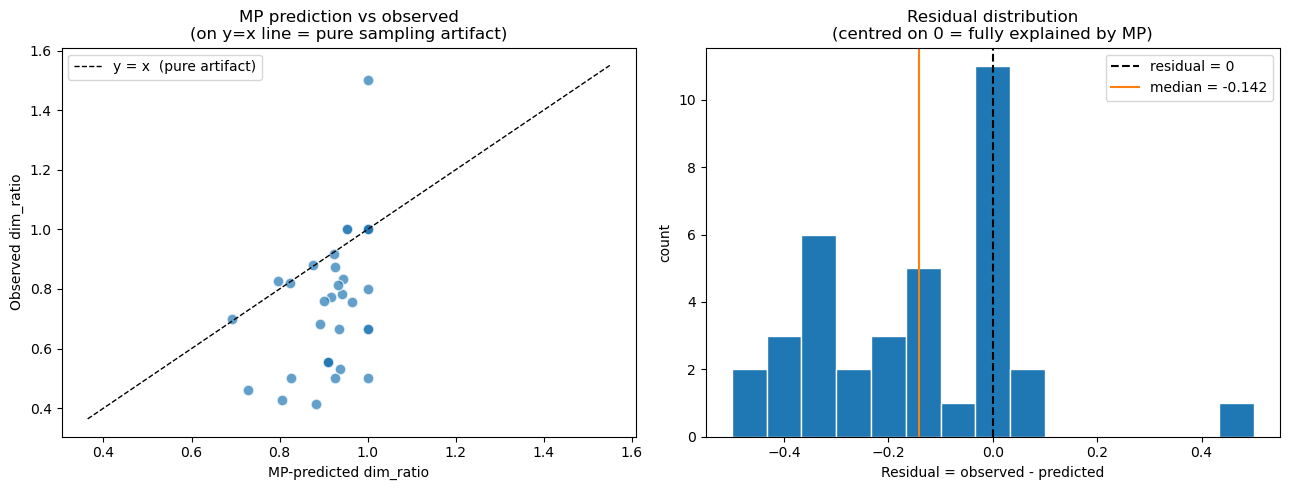


Largest absolute residuals:
                           dataset  n_min  d  c_min  obs_ratio  pred_ratio  residual
               dataset_958_segment    330 18  0.055      0.500       1.000    -0.500
          dataset_1021_page-blocks    560 10  0.018      1.500       1.000     0.500
         dataset_971_mfeat-fourier    200 76  0.380      0.414       0.883    -0.469
     dataset_951_arsenic-male-lung     13  4  0.308      0.500       0.925    -0.425
                  dataset_1049_pc4    178 37  0.208      0.533       0.937    -0.404
                  dataset_1056_mc1     68 38  0.559      0.429       0.806    -0.377
    dataset_767_analcatdata_apnea1     61 11  0.180      0.556       0.909    -0.354
    dataset_765_analcatdata_apnea2     64 11  0.172      0.556       0.909    -0.354
    dataset_764_analcatdata_apnea3     55 11  0.200      0.556       0.909    -0.354
dataset_949_arsenic-female-bladder     80  4  0.050      0.667       1.000    -0.333


In [6]:
# Test 3: Marchenko-Pastur prediction for the PCA dim_ratio
# Self-contained — no cells above need to be run first.
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features

THRESHOLD = 0.95
N_REPS    = 10
SIM_SEED  = 42

def pca_effective_dim(X, threshold=THRESHOLD):
    if X.shape[0] < 2:
        return 1.0
    centred = X - X.mean(axis=0)
    cov = centred.T @ centred / (X.shape[0] - 1)
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
    eigvals = np.maximum(eigvals, 0.0)
    total = eigvals.sum()
    if total == 0:
        return 1.0
    cumvar = np.cumsum(eigvals) / total
    return float(np.searchsorted(cumvar, threshold) + 1)

def mp_q_star(N, d, threshold=THRESHOLD, n_reps=N_REPS, seed=SIM_SEED):
    # Simulate q_c* by generating random Gaussian data from N(0, I_d)
    # and computing the fraction of PCA components needed for `threshold` variance.
    # This is the Marchenko-Pastur prediction under the null (same true covariance).
    if N <= d:
        return min(N - 1, d) / d
    rng = np.random.default_rng(seed)
    fracs = []
    for _ in range(n_reps):
        X = rng.standard_normal((N, d))
        X -= X.mean(axis=0)
        cov = X.T @ X / (N - 1)
        eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
        eigvals = np.maximum(eigvals, 0.0)
        total = eigvals.sum()
        k = int(np.searchsorted(np.cumsum(eigvals) / total, threshold)) + 1
        fracs.append(min(k, d) / d)
    return float(np.mean(fracs))

datasets = load_all_datasets()

rows = []
for ds in datasets:
    X, y = ds.X, binarise_labels(ds.y)
    X = remove_constant_features(X)
    X = StandardScaler().fit_transform(X)
    n_min = int(y.sum())
    n_maj = int((1 - y).sum())
    d = X.shape[1]
    if n_min < max(2, d):
        continue
    obs_ratio  = pca_effective_dim(X[y == 1]) / pca_effective_dim(X[y == 0])
    q_maj      = mp_q_star(n_maj, d)
    q_min      = mp_q_star(n_min, d)
    pred_ratio = q_min / q_maj if q_maj > 0 else float('nan')
    rows.append({
        'dataset':    ds.name,
        'n_min':      n_min,
        'n_maj':      n_maj,
        'd':          d,
        'c_min':      round(d / n_min, 3),
        'c_maj':      round(d / n_maj, 3),
        'obs_ratio':  round(obs_ratio,  3),
        'pred_ratio': round(pred_ratio, 3),
        'residual':   round(obs_ratio - pred_ratio, 3),
    })

mp_df = pd.DataFrame(rows)

print(f'Datasets compared: {len(mp_df)}')
print(f'\nMP-predicted dim_ratio  (sampling artifact only):')
print(f'  median: {mp_df["pred_ratio"].median():.3f}')
print(f'  mean:   {mp_df["pred_ratio"].mean():.3f}')
print(f'\nObserved dim_ratio:')
print(f'  median: {mp_df["obs_ratio"].median():.3f}')
print(f'  mean:   {mp_df["obs_ratio"].mean():.3f}')
print(f'\nResidual = observed - predicted:')
print(f'  median: {mp_df["residual"].median():.3f}')
print(f'  mean:   {mp_df["residual"].mean():.3f}')
print(f'  std:    {mp_df["residual"].std():.3f}')
print(f'  |residual| < 0.10: {(mp_df["residual"].abs() < 0.10).mean():.1%}')
print(f'  |residual| < 0.05: {(mp_df["residual"].abs() < 0.05).mean():.1%}')
print(f'\nCorrelation observed vs predicted: {mp_df["obs_ratio"].corr(mp_df["pred_ratio"]):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(mp_df['pred_ratio'], mp_df['obs_ratio'], alpha=0.7, edgecolors='white', s=60)
lo = min(mp_df['pred_ratio'].min(), mp_df['obs_ratio'].min()) - 0.05
hi = max(mp_df['pred_ratio'].max(), mp_df['obs_ratio'].max()) + 0.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x  (pure artifact)')
ax.set_xlabel('MP-predicted dim_ratio')
ax.set_ylabel('Observed dim_ratio')
ax.set_title('MP prediction vs observed\n(on y=x line = pure sampling artifact)')
ax.legend()

ax = axes[1]
ax.hist(mp_df['residual'], bins=15, edgecolor='white')
ax.axvline(0, color='k', ls='--', lw=1.5, label='residual = 0')
ax.axvline(mp_df['residual'].median(), color='tab:orange', ls='-', lw=1.5,
           label=f'median = {mp_df["residual"].median():.3f}')
ax.set_xlabel('Residual = observed - predicted')
ax.set_ylabel('count')
ax.set_title('Residual distribution\n(centred on 0 = fully explained by MP)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nLargest absolute residuals:')
print(mp_df[['dataset', 'n_min', 'd', 'c_min', 'obs_ratio', 'pred_ratio', 'residual']]
      .reindex(mp_df['residual'].abs().sort_values(ascending=False).index)
      .head(10).to_string(index=False))

### 15.9 Does the geometric signal predict the CV-selected $\alpha$?

The eigenvalue model in §14 proposes using the PCA dimension ratio as a proxy for $\alpha$. §15.8 showed the observed dim_ratio has two components:

$$\text{dim\_ratio} = \underbrace{q_{c_\text{min}}^* / q_{c_\text{maj}}^*}_{\text{MP artifact}} + \underbrace{\delta}_{\text{structural}}$$

The artifact component is pure noise for $\alpha$ prediction — it comes from sample size, not class geometry. The structural component $\delta$ (the residual after subtracting the MP prediction) is the candidate signal.

This cell fits `KNNFairRankCV` on every dataset and reads `best_alpha_` — the $\alpha$ that inner CV selected. It then tests two correlations:

1. **Raw dim_ratio vs $\alpha$** — what §14 proposed to use directly
2. **Structural dim_ratio (residual) vs $\alpha$** — the cleaner signal after removing MP artifact

If either correlation is strong, the geometric model is viable. If both are weak, no fit-time geometric signal can replace CV for $\alpha$ selection.

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Fitting KNNFairRankCV on 49 datasets...
  [ 1/49] dataset_1000_hypothyroid                 alpha=1.0
  [ 2/49] dataset_1002_ipums_la_98-small           alpha=1.0
  [ 3/49] dataset_1004_synthetic_control           alpha=0.25
  [ 4/49] dataset_1013_analcatdata_challenger      alpha=1.0
  [ 5/49] dataset_1014_analcatdata_dmft            alpha=1.0
  [ 6/49] dataset_1016_vowel                       alpha=1.0
  [ 7/49] dataset_1018_ipums_la_99-small           alpha=1.0
  [ 8/49] dataset_1020_mfeat-karhunen              alpha=0.25
  [ 9/49] dataset_1021_page-blocks                 alpha=0.75
  [10/49] dataset_1022_mfeat-pixel                 alpha=0.25
  [11/49] dataset_1023_soybean                     alpha=0.5
  [12/49] dataset_1045_kc1-top5                    alpha=1.0
  [13/49] dataset_1049_pc4                         alpha=0.75
  [14/49] dataset_1050_pc3                         alpha=0.75
  [15/49] dataset_1056_mc1                         alpha=1.0
  [16/49] dataset_1059_ar1             

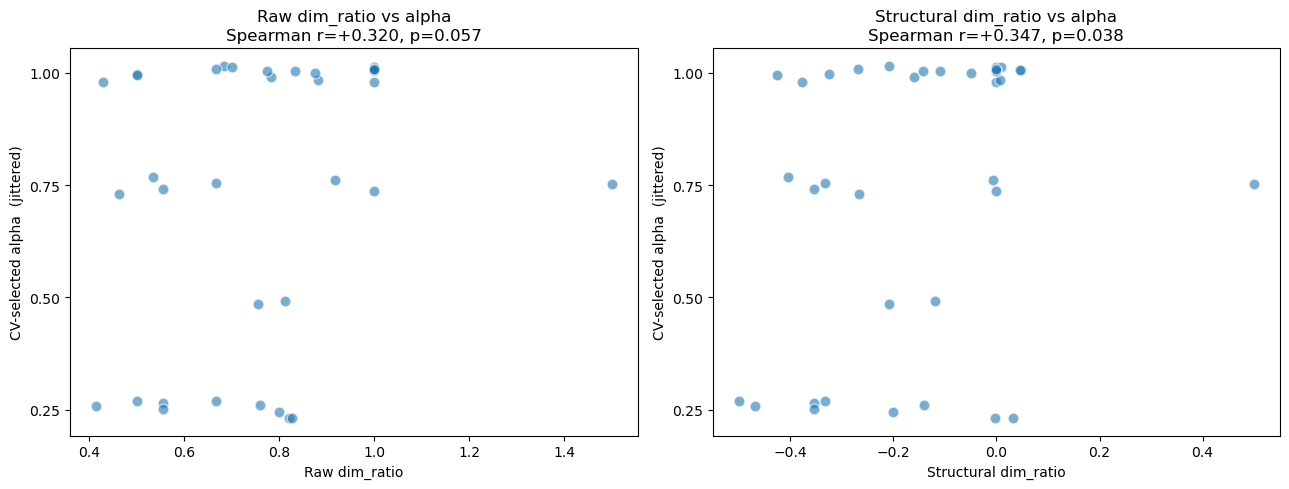


Full table (sorted by best_alpha):
                            dataset    ir  n_min   d  best_alpha  obs_ratio  structural
     dataset_1004_synthetic_control   5.0    100  60        0.25      0.821      -0.002
        dataset_1020_mfeat-karhunen   9.0    200  64        0.25      0.760      -0.140
           dataset_1022_mfeat-pixel   9.0    200 240        0.25        NaN         NaN
                  dataset_312_scene   4.6    431 299        0.25      0.827       0.032
     dataset_765_analcatdata_apnea2   6.4     64  11        0.25      0.556      -0.354
     dataset_764_analcatdata_apnea3   7.2     55  11        0.25      0.556      -0.354
    dataset_962_mfeat-morphological   9.0    200   6        0.25      0.667      -0.333
                dataset_958_segment   6.0    330  18        0.25      0.500      -0.500
         dataset_976_JapaneseVowels   5.2   1614  14        0.25      0.800      -0.200
           dataset_954_spectrometer   8.7     55 100        0.25        NaN         

In [7]:
# Test: does dim_ratio predict the CV-selected alpha?
# Self-contained — no cells above need to be run first.
import sys, warnings
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features
from src.algorithms.knn_fair_rank_c import KNNFairRankCV

THRESHOLD = 0.95
N_REPS    = 10
SIM_SEED  = 42

def pca_effective_dim(X, threshold=THRESHOLD):
    if X.shape[0] < 2:
        return 1.0
    centred = X - X.mean(axis=0)
    cov = centred.T @ centred / (X.shape[0] - 1)
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
    eigvals = np.maximum(eigvals, 0.0)
    total = eigvals.sum()
    if total == 0:
        return 1.0
    cumvar = np.cumsum(eigvals) / total
    return float(np.searchsorted(cumvar, threshold) + 1)

def mp_q_star(N, d, threshold=THRESHOLD, n_reps=N_REPS, seed=SIM_SEED):
    if N <= d:
        return min(N - 1, d) / d
    rng = np.random.default_rng(seed)
    fracs = []
    for _ in range(n_reps):
        X = rng.standard_normal((N, d))
        X -= X.mean(axis=0)
        cov = X.T @ X / (N - 1)
        eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
        eigvals = np.maximum(eigvals, 0.0)
        total = eigvals.sum()
        k = int(np.searchsorted(np.cumsum(eigvals) / total, threshold)) + 1
        fracs.append(min(k, d) / d)
    return float(np.mean(fracs))

datasets = load_all_datasets()
rows = []

print(f'Fitting KNNFairRankCV on {len(datasets)} datasets...')
for i, ds in enumerate(datasets):
    X, y = ds.X, binarise_labels(ds.y)
    X = remove_constant_features(X)
    X = StandardScaler().fit_transform(X)
    n_min = int(y.sum())
    n_maj = int((1 - y).sum())
    d = X.shape[1]

    # Fit CV model and extract selected alpha
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf = KNNFairRankCV(n_jobs=-1)
        clf.fit(X, y)
    best_alpha = clf.best_alpha_

    # Observed dim_ratio
    if n_min >= max(2, d):
        d_maj = pca_effective_dim(X[y == 0])
        d_min = pca_effective_dim(X[y == 1])
        obs_ratio = d_min / d_maj
        q_maj = mp_q_star(n_maj, d)
        q_min = mp_q_star(n_min, d)
        pred_ratio = q_min / q_maj if q_maj > 0 else float('nan')
        structural = obs_ratio - pred_ratio
    else:
        obs_ratio = structural = pred_ratio = float('nan')

    rows.append({
        'dataset':    ds.name,
        'n_min':      n_min,
        'ir':         round(n_maj / max(n_min, 1), 1),
        'd':          d,
        'best_alpha': best_alpha,
        'obs_ratio':  round(obs_ratio,  3) if obs_ratio == obs_ratio else float('nan'),
        'structural': round(structural, 3) if structural == structural else float('nan'),
    })
    print(f'  [{i+1:2d}/{len(datasets)}] {ds.name[:40]:<40} alpha={best_alpha}')

df = pd.DataFrame(rows)
valid = df.dropna(subset=['obs_ratio'])

# Correlations
r_raw,  p_raw  = spearmanr(valid['obs_ratio'],  valid['best_alpha'])
r_str,  p_str  = spearmanr(valid['structural'], valid['best_alpha'])

print(f'\nAlpha distribution across {len(df)} datasets:')
print(df['best_alpha'].value_counts().sort_index().to_string())

print(f'\nCorrelations with CV-selected alpha (Spearman):')
print(f'  Raw dim_ratio vs alpha:        r={r_raw:+.3f},  p={p_raw:.3f}')
print(f'  Structural dim_ratio vs alpha: r={r_str:+.3f},  p={p_str:.3f}')
print(f'  (|r| > 0.4 and p < 0.05 would suggest a useful signal)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label, r_val, p_val in [
    (axes[0], 'obs_ratio',  'Raw dim_ratio',        r_raw,  p_raw),
    (axes[1], 'structural', 'Structural dim_ratio', r_str,  p_str),
]:
    sub = valid.dropna(subset=[col])
    jitter = np.random.default_rng(0).uniform(-0.02, 0.02, len(sub))
    ax.scatter(sub[col], sub['best_alpha'] + jitter, alpha=0.6, edgecolors='white', s=60)
    ax.set_xlabel(label)
    ax.set_ylabel('CV-selected alpha  (jittered)')
    ax.set_title(f'{label} vs alpha\nSpearman r={r_val:+.3f}, p={p_val:.3f}')
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])

plt.tight_layout()
plt.show()

print('\nFull table (sorted by best_alpha):')
print(df[['dataset', 'ir', 'n_min', 'd', 'best_alpha', 'obs_ratio', 'structural']]
      .sort_values('best_alpha').to_string(index=False))

---

## 16. KNNFairRankTopoJoint — Topology Visualisation

Each scatter below is a **PCA(2) projection** of the training set for a selected dataset,
coloured by the Ward-linkage region assigned at fit time.

- **●** = majority sample, **★** = minority sample  
- Each colour = one topological region  
- `k_eff` shown per region — the local rank correction applied to all queries whose nearest
  training neighbour falls in that region  
- Global `r = N_maj / N_min` shown in each title for reference

The second figure shows the **dendrogram gap structure**: the last six merge distances for
each dataset, with a vertical line at the chosen cut. This reveals *why* the algorithm chose
a particular number of regions.

The third figure is a **cross-dataset summary**: per-region `k_eff` values relative to the
global `r`, and per-region minority fraction vs the dataset-wide fraction.

Fitted 41 datasets


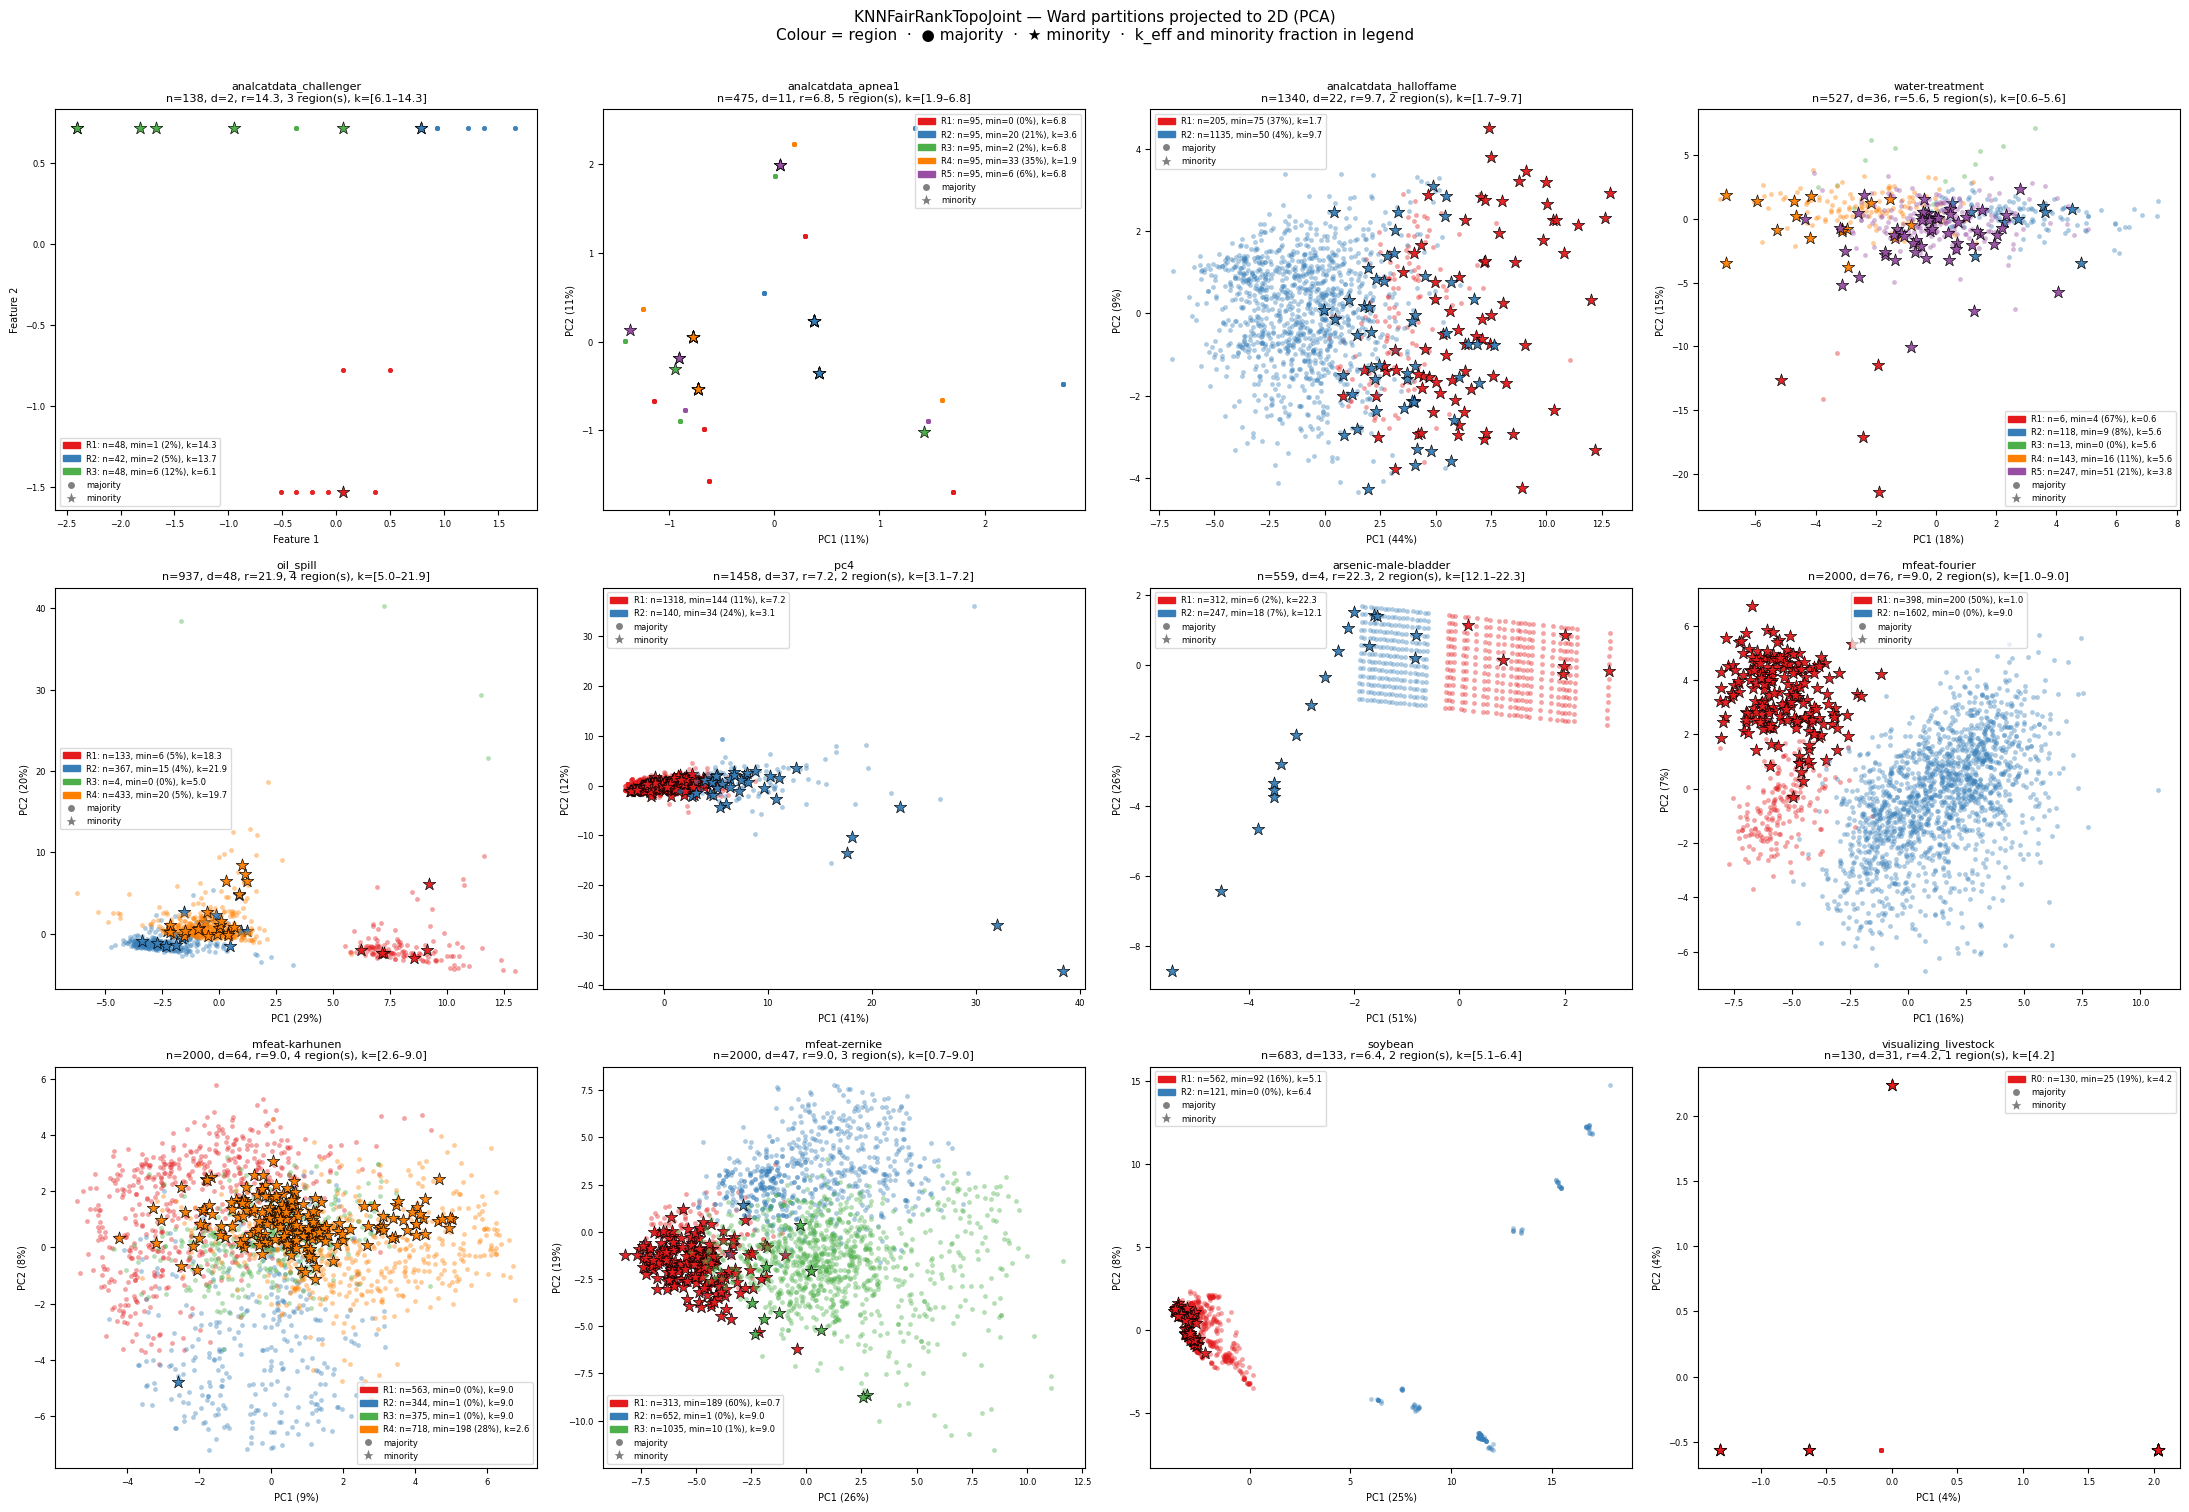

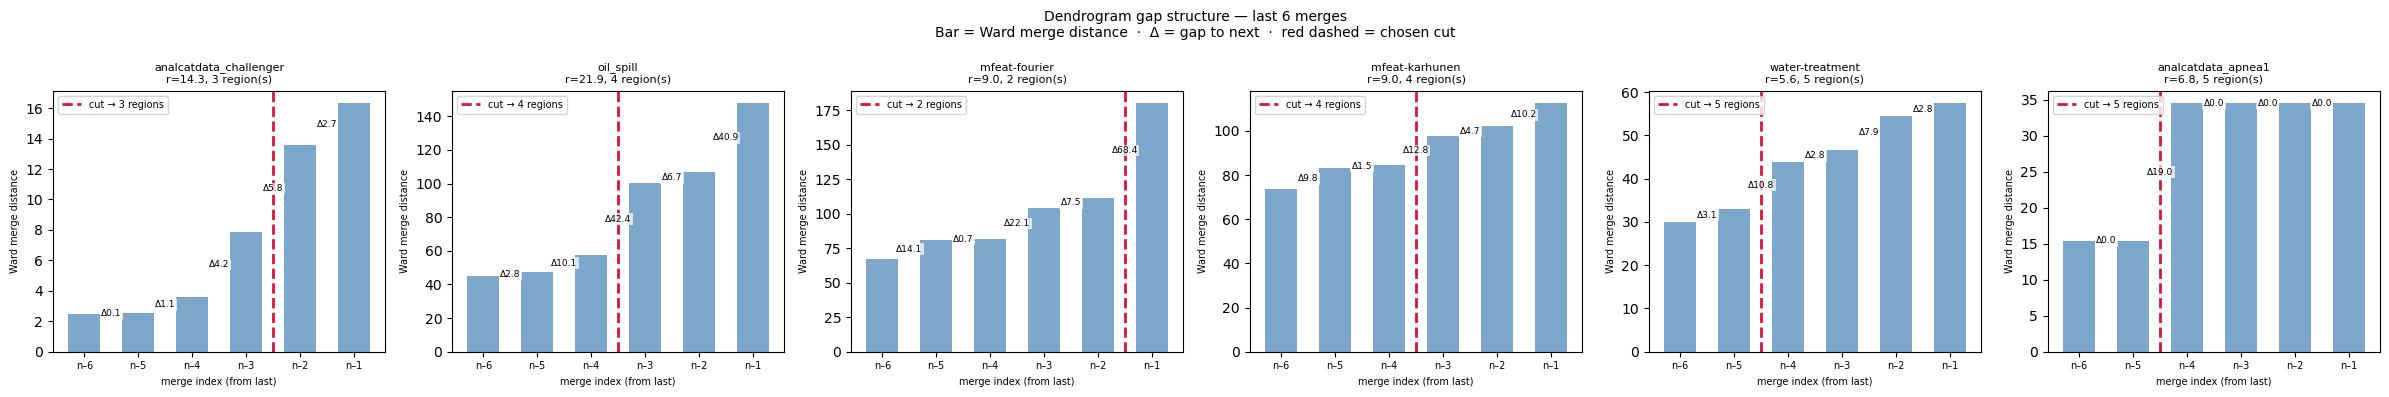

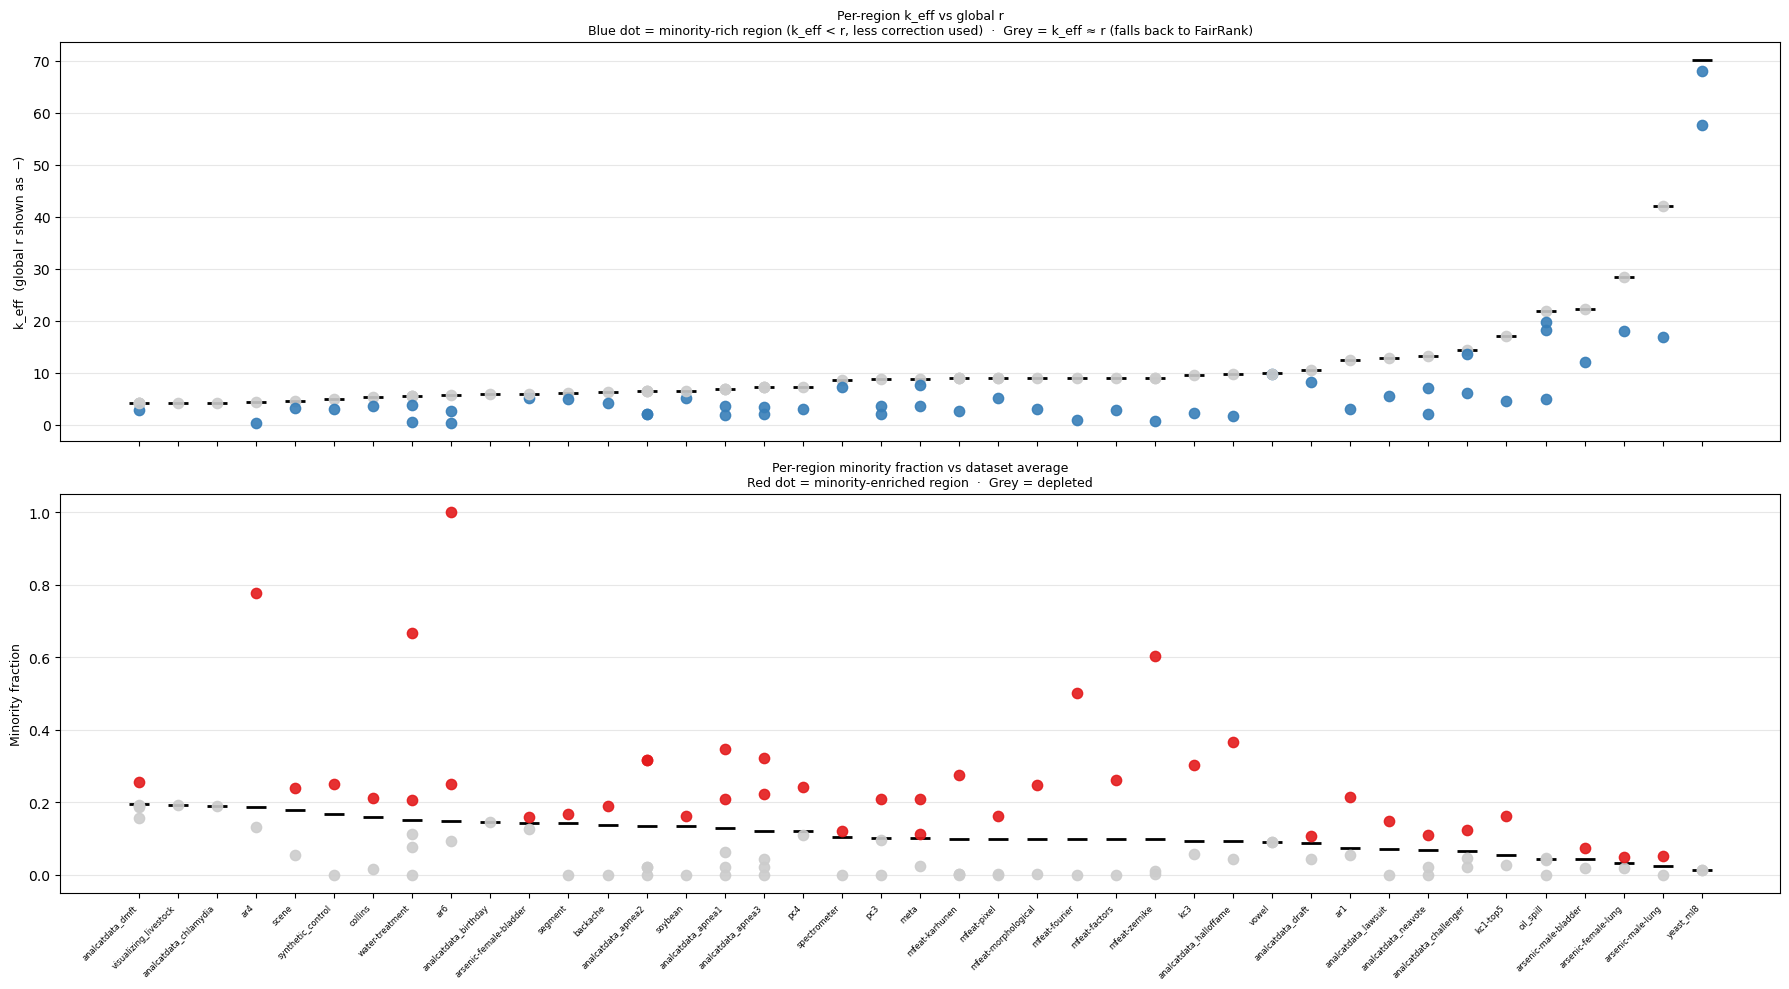

Datasets with largest k_eff spread (most topology signal):
  arsenic-male-lung                              spread=25.21  n_reg=2  r=42.0
  oil_spill                                      spread=16.85  n_reg=4  r=21.9
  kc1-top5                                       spread=12.62  n_reg=2  r=17.1
  analcatdata_neavote                            spread=11.29  n_reg=3  r=13.3
  arsenic-female-lung                            spread=10.42  n_reg=2  r=28.4
  yeast_ml8                                      spread=10.30  n_reg=2  r=70.1
  arsenic-male-bladder                           spread=10.19  n_reg=2  r=22.3
  ar1                                            spread=9.44  n_reg=2  r=12.4
  mfeat-zernike                                  spread=8.34  n_reg=3  r=9.0
  analcatdata_challenger                         spread=8.19  n_reg=3  r=14.3

Datasets where topology found no split (1 region = pure FairRank):
  visualizing_livestock
  analcatdata_chlamydia
  analcatdata_birthday


In [8]:
# § 16  KNNFairRankTopoJoint — Region Visualisation
# Self-contained — no cells above need to be run first.

import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features
from src.algorithms import KNNFairRankTopoJoint

# ── Fit all manageable datasets ───────────────────────────────────────────────
all_ds = load_all_datasets()
fitted = []
for ds in all_ds:
    X_raw, y = ds.X, binarise_labels(ds.y)
    X_raw = remove_constant_features(X_raw)
    X_s = StandardScaler().fit_transform(X_raw)
    n_min = int(y.sum())
    if n_min < 5 or len(X_s) > 3000:
        continue
    clf = KNNFairRankTopoJoint()
    clf.fit(X_s, y)
    fitted.append({'name': ds.name, 'X': X_s, 'y': y, 'clf': clf})
print(f'Fitted {len(fitted)} datasets')

# ── Figure 1: PCA scatter grid — 12 selected datasets ────────────────────────
# Chosen for variety in: n_features, IR, n_regions, geometry.
SELECT = [
    'analcatdata_challenger',   # 2 feat — actual feature axes, 3 regions, r=14
    'analcatdata_apnea1',       # 11 feat, 5 balanced regions (time-series structure)
    'analcatdata_halloffame',   # 22 feat, 2 regions, k_eff=[1.7..9.7] big split
    'water-treatment',          # 36 feat, 5 regions, k_eff=[0.6..5.6]
    'oil_spill',                # 48 feat, 4 regions, high IR r=22
    'pc4',                      # 37 feat, software-defects, 2 regions
    'arsenic-male-bladder',     # 4 feat, 2 regions, very high IR r=22
    'mfeat-fourier',            # 76 feat, 2 regions, k_eff=[1.0..9.0] extreme split
    'mfeat-karhunen',           # 64 feat, 4 regions, k_eff=[2.6..9.0]
    'mfeat-zernike',            # 47 feat, 3 regions, k_eff=[0.7..9.0]
    'soybean',                  # 133 feat, 2 regions — all minority in one region
    'visualizing_livestock',    # fallback: 1 region = pure FairRank
]

selected = [d for target in SELECT
            for d in fitted if target in d['name']][:12]

REGION_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

n_cols = 4
n_rows = int(np.ceil(len(selected) / n_cols))
fig1, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.ravel()

for ax, d in zip(axes, selected):
    X_s, y, clf = d['X'], d['y'], d['clf']
    n_feat = X_s.shape[1]

    if n_feat == 2:
        X_2d = X_s
        ax_labels = ('Feature 1', 'Feature 2')
    else:
        pca = PCA(n_components=2, random_state=0)
        X_2d = pca.fit_transform(X_s)
        ev = pca.explained_variance_ratio_
        ax_labels = (f'PC1 ({ev[0]:.0%})', f'PC2 ({ev[1]:.0%})')

    regions = np.unique(clf._point_region)
    legend_handles = []
    for i, rid in enumerate(regions):
        mask_r = clf._point_region == rid
        col = REGION_COLORS[i % len(REGION_COLORS)]
        ke = clf._region_k_eff[int(rid)]
        sz = int(mask_r.sum())
        n_min_r = int(np.sum(mask_r & (y == 1)))
        min_frac = n_min_r / sz if sz > 0 else 0

        mask_maj = mask_r & (y == 0)
        mask_min = mask_r & (y == 1)
        if mask_maj.any():
            ax.scatter(X_2d[mask_maj, 0], X_2d[mask_maj, 1],
                       c=col, marker='o', s=12, alpha=0.4, linewidths=0)
        if mask_min.any():
            ax.scatter(X_2d[mask_min, 0], X_2d[mask_min, 1],
                       c=col, marker='*', s=90, alpha=0.95,
                       linewidths=0.5, edgecolors='k')
        legend_handles.append(mpatches.Patch(
            color=col,
            label=f'R{int(rid)}: n={sz}, min={n_min_r} ({min_frac:.0%}), k={ke:.1f}'
        ))

    legend_handles += [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
               markersize=6, label='majority'),
        Line2D([0],[0], marker='*', color='w', markerfacecolor='grey',
               markersize=11, label='minority'),
    ]
    ax.legend(handles=legend_handles, fontsize=6, loc='best', framealpha=0.7)

    short_name = d['name'].split('_', 2)[-1]
    n_regions = clf.n_regions_
    k_vals = list(clf._region_k_eff.values())
    k_range = f'[{min(k_vals):.1f}–{max(k_vals):.1f}]' if n_regions > 1 else f'[{k_vals[0]:.1f}]'
    ax.set_title(
        f'{short_name}\n'
        f'n={len(X_s)}, d={n_feat}, r={clf._r:.1f}, '
        f'{n_regions} region(s), k={k_range}',
        fontsize=8
    )
    ax.set_xlabel(ax_labels[0], fontsize=7)
    ax.set_ylabel(ax_labels[1], fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes[len(selected):]:
    ax.set_visible(False)

fig1.suptitle(
    'KNNFairRankTopoJoint — Ward partitions projected to 2D (PCA)\n'
    'Colour = region  ·  ● majority  ·  ★ minority  ·  k_eff and minority fraction in legend',
    fontsize=11, y=1.005
)
plt.tight_layout()
plt.show()


# ── Figure 2: Dendrogram gap structure ───────────────────────────────────────
GAP_SELECT = [
    'analcatdata_challenger',
    'oil_spill',
    'mfeat-fourier',
    'mfeat-karhunen',
    'water-treatment',
    'analcatdata_apnea1',
]
gap_items = [d for target in GAP_SELECT
             for d in fitted if target in d['name']][:6]

n_g = len(gap_items)
fig2, axes2 = plt.subplots(1, n_g, figsize=(4 * n_g, 4), sharey=False)
if n_g == 1:
    axes2 = [axes2]

for ax, d in zip(axes2, gap_items):
    X_s, clf = d['X'], d['clf']
    Z = linkage(X_s, method='ward')
    md = Z[:, 2]
    n = len(X_s)
    SHOW = min(6, len(md))
    tail = md[-SHOW:]

    ax.bar(np.arange(SHOW), tail, color='steelblue', alpha=0.7, width=0.6)

    # Gap labels between bars
    tail_gaps = np.diff(tail)
    for j, g in enumerate(tail_gaps):
        ax.text(j + 0.5, (tail[j] + tail[j+1]) / 2,
                f'Δ{g:.1f}', ha='center', va='center',
                fontsize=6.5, color='k',
                bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

    # Chosen cut
    max_reg = clf._max_regions
    lo_global = max(0, len(md) - max_reg)
    best_global = lo_global + int(np.argmax(np.diff(md[lo_global:])))
    tail_start = len(md) - SHOW
    cut_in_tail = best_global - tail_start
    if 0 <= cut_in_tail < SHOW - 1:
        ax.axvline(cut_in_tail + 0.5, color='crimson', lw=2, ls='--',
                   label=f'cut → {n - best_global - 1} regions')
        ax.legend(fontsize=7, loc='upper left')

    ax.set_xticks(np.arange(SHOW))
    ax.set_xticklabels(
        [f'n–{SHOW-i}' for i in range(SHOW)],
        fontsize=7
    )
    ax.set_xlabel('merge index (from last)', fontsize=7)
    ax.set_ylabel('Ward merge distance', fontsize=7)
    short = d['name'].split('_', 2)[-1]
    ax.set_title(f'{short}\nr={clf._r:.1f}, {clf.n_regions_} region(s)', fontsize=8)

fig2.suptitle(
    'Dendrogram gap structure — last 6 merges\n'
    'Bar = Ward merge distance  ·  Δ = gap to next  ·  red dashed = chosen cut',
    fontsize=10
)
plt.tight_layout()
plt.show()


# ── Figure 3: Cross-dataset summary ──────────────────────────────────────────
fitted_sorted = sorted(fitted, key=lambda d: d['clf']._r)
x_pos = np.arange(len(fitted_sorted))
ds_names_short = [d['name'].split('_', 2)[-1] for d in fitted_sorted]

fig3, (ax3a, ax3b) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

for i, d in enumerate(fitted_sorted):
    clf = d['clf']
    r = clf._r
    y_arr = d['y']

    # k_eff panel
    ax3a.plot(i, r, '_', color='black', markersize=14, markeredgewidth=2)
    for ke in clf._region_k_eff.values():
        color = '#377eb8' if ke < r - 0.2 else '#cccccc'
        ax3a.scatter(i, ke, color=color, s=55, zorder=3, alpha=0.9)

    # Minority fraction panel
    global_frac = float(y_arr.sum()) / len(y_arr)
    ax3b.plot(i, global_frac, '_', color='black', markersize=14, markeredgewidth=2)
    for rid in np.unique(clf._point_region):
        mask_r = clf._point_region == rid
        sz = mask_r.sum()
        min_frac = float(np.sum(mask_r & (y_arr == 1))) / sz if sz > 0 else 0
        color = '#e41a1c' if min_frac > global_frac + 0.01 else '#cccccc'
        ax3b.scatter(i, min_frac, s=55, alpha=0.9, color=color, zorder=3)

ax3a.set_ylabel('k_eff  (global r shown as  ─)', fontsize=9)
ax3a.set_title(
    'Per-region k_eff vs global r\n'
    'Blue dot = minority-rich region (k_eff < r, less correction used)  ·  '
    'Grey = k_eff ≈ r (falls back to FairRank)',
    fontsize=9
)
ax3b.set_ylabel('Minority fraction', fontsize=9)
ax3b.set_title(
    'Per-region minority fraction vs dataset average\n'
    'Red dot = minority-enriched region  ·  Grey = depleted',
    fontsize=9
)
ax3b.set_xticks(x_pos)
ax3b.set_xticklabels(ds_names_short, rotation=45, ha='right', fontsize=6)
for ax in (ax3a, ax3b):
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ── Text summary ──────────────────────────────────────────────────────────────
print('Datasets with largest k_eff spread (most topology signal):')
spreads = [
    (d['name'].split('_', 2)[-1],
     max(d['clf']._region_k_eff.values()) - min(d['clf']._region_k_eff.values()),
     d['clf'].n_regions_,
     d['clf']._r)
    for d in fitted
]
spreads.sort(key=lambda x: -x[1])
for name, spread, nreg, r in spreads[:10]:
    print(f'  {name:<45}  spread={spread:.2f}  n_reg={nreg}  r={r:.1f}')

print('\nDatasets where topology found no split (1 region = pure FairRank):')
for d in fitted:
    if d['clf'].n_regions_ == 1:
        nm = d['name'].split('_', 2)[-1]
        print(f'  {nm}')


---

## 17. Future directions for KNNFairRankTopoJoint

### 17.1 Replace `max_regions` with `min_region_samples`

**Current limitation.** The Ward cut is restricted to the last `max_regions - 1 = 4` dendrogram gaps — a blunt instrument. It prevents fine-grained fragmentation, but a region of 5 points in a 1000-sample dataset is still possible if the gap happens to land there. The per-region imbalance estimate `(n_maj + lambda) / (n_min + lambda)` is meaningless with so few points.

**Proposed fix.** Replace `max_regions` with `min_region_samples`. Scan candidate cuts from coarsest (2 clusters) to finest and accept the finest cut where **every** region has >= `min_region_samples` points AND the gap criterion (`min_persistence_ratio`) is satisfied.

This guards a different failure mode: statistical reliability of per-region estimates rather than fragmentation count. The two criteria together:
- `min_persistence_ratio` — the structural gap must be geometrically real (not sampling noise in distances)
- `min_region_samples` — each resulting region must have enough data for a meaningful imbalance ratio

A sensible adaptive default: `max(10, int(0.05 * n_train))` — at least 10 samples, or 5% of training set, whichever is larger.

---

### 17.2 Per-class density ratio instead of joint-cloud clustering

**Current limitation.** Ward clustering is driven by **joint** point cloud density, dominated by the majority class (more points = more influence on the dendrogram). Region boundaries reflect where the *combined population* clusters, not where the *class densities diverge*.

Concretely: if minority points are densely packed in a corner alongside many majority points, Ward sees high joint density, creates one joint region, and counts n_maj and n_min inside it. But the fact that minority is *locally denser than its global average* relative to majority is not what drove the region boundary. The individual density contribution of each class to that region is unknown — we only see the aggregate count.

**What we actually want.** The quantity that matters for FairRank is the **density ratio**:

$$\rho(x) = \frac{\rho_{\mathrm{maj}}(x)}{\rho_{\mathrm{min}}(x)}$$

Zones where this ratio is small (minority locally concentrated relative to majority) should get a milder correction; zones where it matches the global IR fall back to standard FairRank.

**Proposed approach.**

1. For each training point $x_i$, estimate local majority density independently via k-NN: $\hat{\rho}_{\mathrm{maj}}(x_i) \propto 1 / d_{k,\mathrm{maj}}^{d_{\mathrm{eff}}}$ (distance to k-th majority neighbour, $d_{\mathrm{eff}}$ = intrinsic dimensionality)
2. Same for minority: $\hat{\rho}_{\mathrm{min}}(x_i) \propto 1 / d_{k,\mathrm{min}}^{d_{\mathrm{eff}}}$
3. Compute per-point ratio $r(x_i) = \hat{\rho}_{\mathrm{maj}} / \hat{\rho}_{\mathrm{min}}$
4. Cluster or threshold on **that ratio** — not on spatial proximity of the joint cloud

This directly answers where minority concentrates relative to majority, instead of where the combined cloud clusters.

**Why not `knn_fair_rank_local_odds.py`?** That version uses raw vote counts $(n_{\mathrm{maj},knn} / n_{\mathrm{min},knn})$ which are very noisy for small k and react to every local fluctuation, causing systematic under-correction on scattered-minority datasets. K-NN density estimates with a larger bandwidth $k_{\mathrm{density}} > k_{\mathrm{vote}}$ decouple the density estimation scale from the voting scale and produce a smoother, more stable ratio surface.

**Key hyperparameter.** $k_{\mathrm{density}}$ is independent of the FairRank voting k. Larger $k_{\mathrm{density}}$ gives a smoother ratio surface and more conservative region boundaries.

---

## 18. Convergence-rate density ratio — majority exhaustion hypothesis

**Idea.** For a query point $x$, scan outward through minority neighbours in order of distance.
At each rank $j$, count how many majority training points are closer to $x$ than the $j$-th minority neighbour:

$$\hat{k}_{\mathrm{eff}}(j) = \frac{\#\{i : d_{\mathrm{maj},i}(x) < d_{j,\mathrm{min}}(x)\}}{j}$$

This is a running estimate of the local density ratio. As $j$ grows the estimate should converge to a
plateau whose value is the local correction we want to apply in FairRank.

**The exhaustion point** is the first $j^*$ where all $N_{\mathrm{maj}}$ training majority points have been
counted (i.e. $d_{j^*,\mathrm{min}}(x)$ has grown past every majority neighbour).
After $j^*$ the curve collapses as $N_{\mathrm{maj}}/j$ — a decaying artefact.
The plateau *before* $j^*$ is the meaningful estimate.

**Two approaches are compared:**
- **A — counting:** $\hat{k}(j)$ as above. Captures the density ratio at varying spatial scales.
- **B — rank ratio:** $d_{j,\mathrm{min}}(x) / d_{j,\mathrm{maj}}(x)$ (same rank, different class).
  Noisier but directly mirrors the FairRank comparison structure.

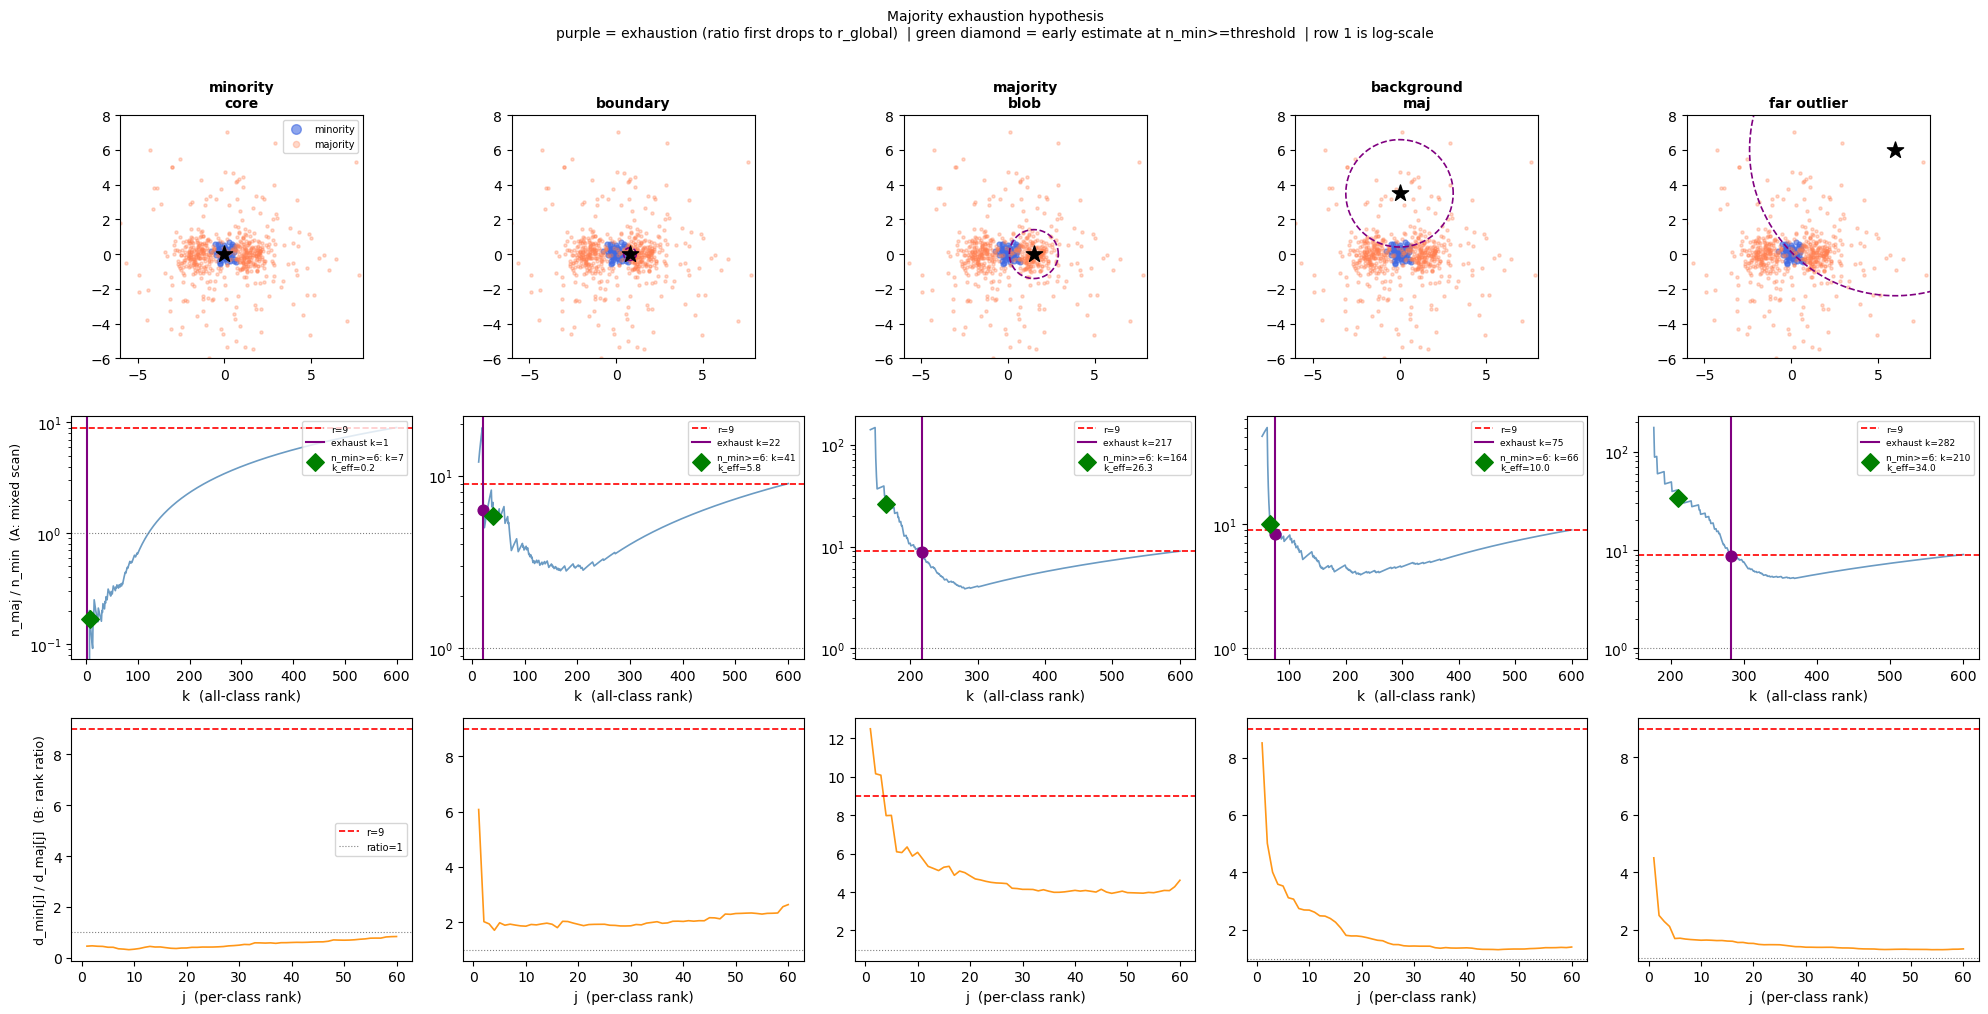

Global r = 9.0   |   n_min threshold = 6

Query                  exhaust k  k_eff@thresh   exhaust d
----------------------------------------------------------
minority core                  1          0.17       0.058
boundary                      22          5.83       0.362
majority blob                217         26.33       1.409
background maj                75         10.00       3.094
far outlier                  282         34.00       8.401

Interpretation:
  k_eff @ thresh << r  ->  minority locally concentrated  -> mild correction
  k_eff @ thresh ~  r  ->  matches global ratio           -> standard FairRank
  k_eff @ thresh >> r  ->  majority locally concentrated  -> stronger correction
  exhaustion "never"   ->  minority is always the denser class from x (core)


In [9]:
# SS 18  Convergence-rate density ratio -- majority exhaustion hypothesis
# Self-contained -- no cells above need to be run first.

import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)

# Controlled 2-D synthetic dataset
# Minority: tight cluster at origin.
# Majority: two flanking blobs + scattered background. IR = 9.
N_min = 60
N_maj = 540

X_min = rng.randn(N_min, 2) * 0.3
X_maj = np.vstack([
    rng.randn(N_maj // 3, 2) * 0.6 + np.array([ 1.5,  0.0]),
    rng.randn(N_maj // 3, 2) * 0.6 + np.array([-1.5,  0.0]),
    rng.randn(N_maj - 2*(N_maj//3), 2) * 3.0,
])
r_global = N_maj / N_min

query_points = {
    'minority\ncore':   np.array([ 0.0,  0.0]),
    'boundary':          np.array([ 0.8,  0.0]),
    'majority\nblob':   np.array([ 1.5,  0.0]),
    'background\nmaj':  np.array([ 0.0,  3.5]),
    'far outlier':       np.array([ 6.0,  6.0]),
}

def mixed_scan(x, X_min, X_maj, r_global):
    d_min_all = np.linalg.norm(X_min - x, axis=1)
    d_maj_all = np.linalg.norm(X_maj - x, axis=1)
    all_d = np.concatenate([d_min_all, d_maj_all])
    all_y = np.array([0]*len(d_min_all) + [1]*len(d_maj_all))
    order = np.argsort(all_d)
    y_s = all_y[order]
    d_s = all_d[order]
    n_min_cum = np.cumsum(y_s == 0).astype(float)
    n_maj_cum = np.cumsum(y_s == 1).astype(float)
    ratio = np.where(n_min_cum > 0, n_maj_cum / np.maximum(n_min_cum, 1), np.nan)
    # Exhaustion: first k where ratio first drops at/below r_global
    above_r = ratio > r_global
    ex_candidates = np.where(~np.isnan(ratio) & ~above_r)[0]
    ex_k = int(ex_candidates[0]) if len(ex_candidates) > 0 else None
    # Early estimate: ratio at first k where n_min >= threshold
    n_thresh = max(3, len(X_min) // 10)
    est_candidates = np.where(n_min_cum >= n_thresh)[0]
    est_k = int(est_candidates[0]) if len(est_candidates) > 0 else None
    return ratio, d_s, n_min_cum, ex_k, est_k

def rank_ratio(x, X_min, X_maj):
    d_min = np.sort(np.linalg.norm(X_min - x, axis=1))
    d_maj = np.sort(np.linalg.norm(X_maj - x, axis=1))
    n = min(len(d_min), len(d_maj))
    return d_min[:n] / np.maximum(d_maj[:n], 1e-12)

n_q = len(query_points)
fig, axes = plt.subplots(3, n_q, figsize=(4*n_q, 10))

for col, (label, x) in enumerate(query_points.items()):
    ratio_A, d_s, n_min_cum, ex_k, est_k = mixed_scan(x, X_min, X_maj, r_global)
    ratio_B = rank_ratio(x, X_min, X_maj)

    # Row 0: spatial context
    ax = axes[0, col]
    ax.scatter(X_min[:,0], X_min[:,1], c='royalblue', s=12, alpha=0.6, label='minority')
    ax.scatter(X_maj[:,0], X_maj[:,1], c='coral', s=5, alpha=0.3, label='majority')
    ax.scatter(*x, c='black', s=150, marker='*', zorder=6)
    r_circ = d_s[ex_k] if ex_k is not None else d_s[-1]
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(x[0]+r_circ*np.cos(theta), x[1]+r_circ*np.sin(theta),
            c='purple' if ex_k is not None else 'gray', lw=1.2, ls='--')
    ax.set_xlim(-6, 8); ax.set_ylim(-6, 8)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=10, fontweight='bold')
    if col == 0:
        ax.legend(fontsize=7, markerscale=2)

    # Row 1: Approach A (mixed scan, log scale)
    ax = axes[1, col]
    ks = np.arange(1, len(ratio_A) + 1)
    ax.plot(ks, ratio_A, c='steelblue', lw=1.2, alpha=0.8)
    ax.axhline(r_global, c='red', ls='--', lw=1.2, label=f'r={r_global:.0f}')
    ax.axhline(1.0, c='gray', ls=':', lw=0.8)
    if ex_k is not None:
        ax.axvline(ex_k+1, c='purple', lw=1.5, label=f'exhaust k={ex_k+1}')
        ax.scatter([ex_k+1], [ratio_A[ex_k]], c='purple', s=60, zorder=5)
    if est_k is not None:
        n_thresh = max(3, N_min // 10)
        ax.scatter([est_k+1], [ratio_A[est_k]], c='green', s=80, marker='D', zorder=6,
                   label=f'n_min>={n_thresh}: k={est_k+1}\nk_eff={ratio_A[est_k]:.1f}')
    ax.set_xlabel('k  (all-class rank)')
    ax.set_yscale('log')
    ax.legend(fontsize=6.5, loc='upper right')
    if col == 0:
        ax.set_ylabel('n_maj / n_min  (A: mixed scan)', fontsize=9)

    # Row 2: Approach B (rank ratio)
    ax = axes[2, col]
    js = np.arange(1, len(ratio_B) + 1)
    ax.plot(js, ratio_B, c='darkorange', lw=1.2, alpha=0.9)
    ax.axhline(r_global, c='red', ls='--', lw=1.2, label=f'r={r_global:.0f}')
    ax.axhline(1.0, c='gray', ls=':', lw=0.8, label='ratio=1')
    ax.set_xlabel('j  (per-class rank)')
    if col == 0:
        ax.set_ylabel('d_min[j] / d_maj[j]  (B: rank ratio)', fontsize=9)
        ax.legend(fontsize=7)

plt.suptitle(
    'Majority exhaustion hypothesis\n'
    'purple = exhaustion (ratio first drops to r_global)  '
    '| green diamond = early estimate at n_min>=threshold  | row 1 is log-scale',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

# Summary table
n_thresh = max(3, N_min // 10)
print(f'Global r = {r_global:.1f}   |   n_min threshold = {n_thresh}\n')
print(f'{"Query":<20}  {"exhaust k":>10}  {"k_eff@thresh":>12}  {"exhaust d":>10}')
print('-' * 58)
for label, x in query_points.items():
    ratio_A, d_s, _, ex_k, est_k = mixed_scan(x, X_min, X_maj, r_global)
    tag = label.replace('\n', ' ')
    ex_str  = f'{ex_k+1}' if ex_k is not None else 'never'
    est_str = f'{ratio_A[est_k]:.2f}' if est_k is not None else '—'
    d_str   = f'{d_s[ex_k]:.3f}' if ex_k is not None else '—'
    print(f'{tag:<20}  {ex_str:>10}  {est_str:>12}  {d_str:>10}')

print()
print('Interpretation:')
print('  k_eff @ thresh << r  ->  minority locally concentrated  -> mild correction')
print('  k_eff @ thresh ~  r  ->  matches global ratio           -> standard FairRank')
print('  k_eff @ thresh >> r  ->  majority locally concentrated  -> stronger correction')
print('  exhaustion "never"   ->  minority is always the denser class from x (core)')


---

## 19. Generalising the exhaustion test into a local density ratio estimator

From the mixed scan in §18 we can read off: the ratio
$n_{\mathrm{maj}}(k) / n_{\mathrm{min}}(k)$ at the moment $n_{\mathrm{min}}$ first
reaches a reference count $k_{\mathrm{ref}}$ equals

$$
\hat{k}_{\mathrm{eff}}(x;\,k_{\mathrm{ref}})
= \frac{\#\{i : \|x_i^{(\mathrm{maj})} - x\| \le d_{k_{\mathrm{ref}},\mathrm{min}}(x)\}}{k_{\mathrm{ref}}}
$$

where $d_{k,\mathrm{min}}(x)$ is the distance to the $k$-th nearest minority training point.
This is a **nonparametric local density ratio**: it counts how many majority points fit
inside the sphere that just barely contains $k_{\mathrm{ref}}$ minority points.

A second candidate from Poisson theory:

$$
\hat{k}_{\mathrm{eff}}^{\mathrm{rank}}(x;\,k_{\mathrm{ref}},d_{\mathrm{eff}})
= \left(\frac{d_{k_{\mathrm{ref}},\mathrm{min}}(x)}{d_{k_{\mathrm{ref}},\mathrm{maj}}(x)}\right)^{d_{\mathrm{eff}}}
$$

Both equal $\rho_{\mathrm{maj}}/\rho_{\mathrm{min}}$ under uniform density.
The counting formula **does not require $d_{\mathrm{eff}}$** and handles non-uniform geometry;
the rank-ratio formula is cheaper (two $k$-NN lookups) but fails when minority and majority
occupy different spatial scales — as the outlier case in §18 demonstrates.

**Key hyperparameter:** $k_{\mathrm{ref}}$ controls the estimation scale.
Small $k_{\mathrm{ref}}$ = very local but noisy; large $k_{\mathrm{ref}}$ = stable but biased toward
the global ratio. A natural default: $k_{\mathrm{ref}} = \max(3,\lfloor\sqrt{N_{\mathrm{min}}}\rfloor)$.

Formula A (counting)  vs  Formula B (rank ratio^d_eff=2)
k_ref  : [1, 3, 6, 10, 20]                     |   same
---------------------------------------------------------------------------
minority core     A:    0.0    0.0    0.2    0.1    0.2   B:    0.2    0.2    0.2    0.1    0.2
boundary          A:   12.0    6.3    5.8    5.3    3.9   B:   36.9    3.7    3.6    3.4    3.7
majority blob     A:  140.0   49.0   26.3   17.4    9.4   B:  156.2  101.7   37.2   36.8   23.5
background        A:   51.0   20.0   10.0    7.6    5.2   B:   72.4   16.1    9.7    7.2    3.1
far outlier       A:  176.0   59.7   34.0   23.1   12.5   B:   20.3    5.2    2.9    2.7    2.3
  note: r_global = 9   -- values >> r indicate locally minority-sparse


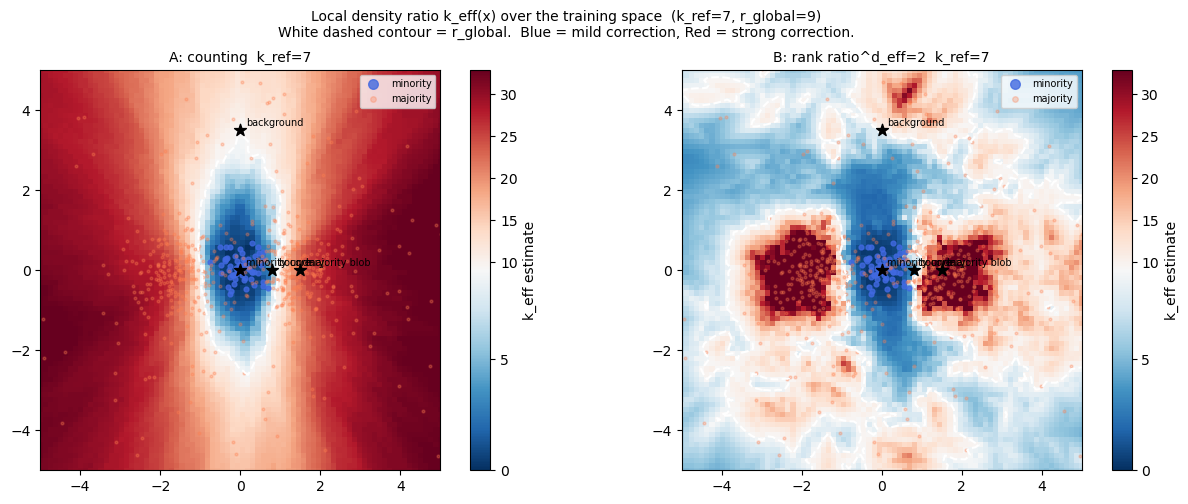

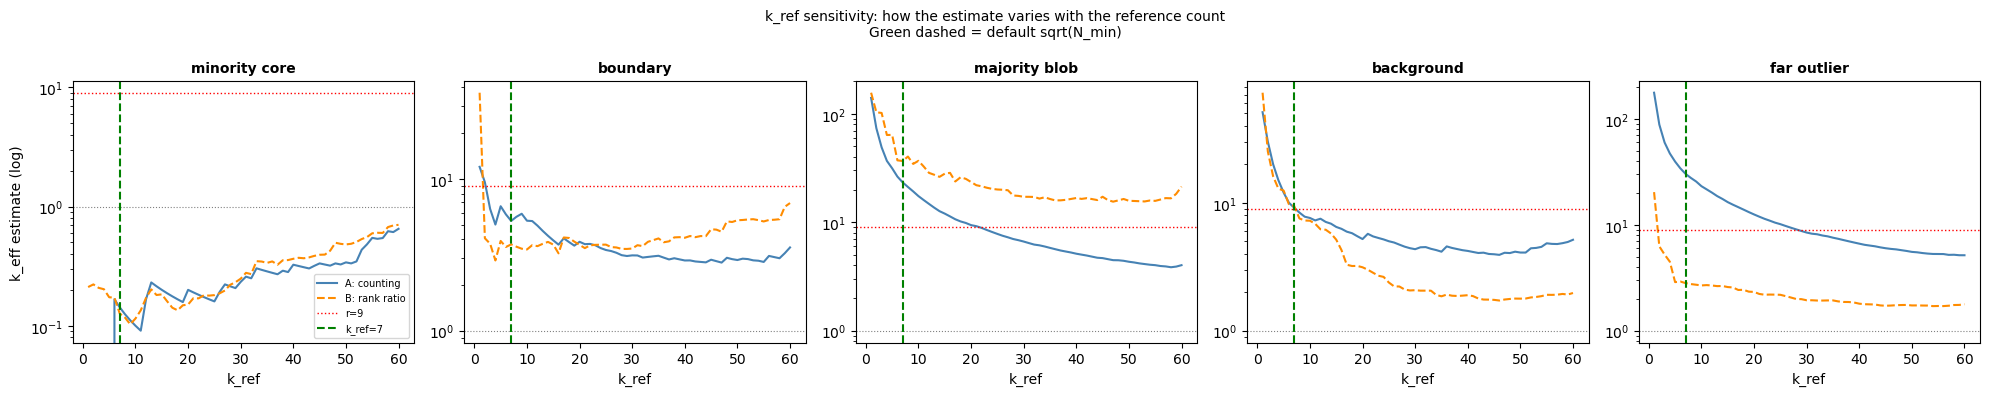

Default k_ref = sqrt(N_min) = 7
Global r = 9.0

Query               A (counting)   B (rank ratio)  note
-----------------------------------------------------------------
minority core               0.14             0.13  no correction (minority dense)
boundary                    5.29             3.70  
majority blob              23.29            36.67  very strong correction
background                  9.14             9.43  approx standard FairRank
far outlier                30.14             2.81  very strong correction

Formula A is robust; Formula B fails for the outlier (wrong scale assumption).
Formula A cost at predict time: one k-NN on X_min + one range query on X_maj.


In [10]:
# SS 19  Local density ratio estimator -- formula derivation and spatial sweep
# Self-contained -- no cells above need to be run first.

import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rng = np.random.RandomState(0)
N_min = 60; N_maj = 540
X_min = rng.randn(N_min, 2) * 0.3
X_maj = np.vstack([
    rng.randn(N_maj // 3, 2) * 0.6 + np.array([ 1.5,  0.0]),
    rng.randn(N_maj // 3, 2) * 0.6 + np.array([-1.5,  0.0]),
    rng.randn(N_maj - 2*(N_maj//3), 2) * 3.0,
])
r_global = N_maj / N_min

# --- formula A: counting estimator -------------------------------------------
def keff_counting(x, X_min, X_maj, k_ref):
    '''
    #{maj within d_{k_ref,min}(x)} / k_ref.
    Nonparametric; no d_eff assumption.
    '''
    d_min = np.sort(np.linalg.norm(X_min - x, axis=1))
    if k_ref > len(d_min):
        return np.nan
    radius = d_min[k_ref - 1]
    d_maj = np.linalg.norm(X_maj - x, axis=1)
    return float(np.sum(d_maj <= radius)) / k_ref

# --- formula B: rank-ratio estimator -----------------------------------------
def keff_rank_ratio(x, X_min, X_maj, k_ref, d_eff):
    '''
    (d_{k_ref,min} / d_{k_ref,maj})^d_eff.
    Valid under locally uniform density (same d_eff for both classes).
    '''
    d_min = np.sort(np.linalg.norm(X_min - x, axis=1))
    d_maj = np.sort(np.linalg.norm(X_maj - x, axis=1))
    if k_ref > len(d_min) or k_ref > len(d_maj):
        return np.nan
    return float((d_min[k_ref-1] / max(d_maj[k_ref-1], 1e-12)) ** d_eff)

# ---- k_ref sensitivity table ------------------------------------------------
query_points = {
    'minority core':  np.array([ 0.0,  0.0]),
    'boundary':       np.array([ 0.8,  0.0]),
    'majority blob':  np.array([ 1.5,  0.0]),
    'background':     np.array([ 0.0,  3.5]),
    'far outlier':    np.array([ 6.0,  6.0]),
}
d_eff_true = 2.0
k_refs = [1, 3, 6, 10, 20]

print('Formula A (counting)  vs  Formula B (rank ratio^d_eff=2)')
print(f'k_ref  : {str(k_refs):<35}   |   same')
print('-' * 75)
for label, x in query_points.items():
    rowA = [f'{keff_counting(x, X_min, X_maj, k):6.1f}' for k in k_refs]
    rowB = [f'{keff_rank_ratio(x, X_min, X_maj, k, d_eff_true):6.1f}' for k in k_refs]
    print(f'{label:<16}  A: {" ".join(rowA)}   B: {" ".join(rowB)}')
print(f'  note: r_global = {r_global:.0f}   -- values >> r indicate locally minority-sparse')

# ---- spatial heatmap: k_eff_counting over a 2-D grid -----------------------
k_ref_default = max(3, int(np.sqrt(N_min)))   # = 7 for N_min=60

grid_lim = 5.0
res = 80
gx = np.linspace(-grid_lim, grid_lim, res)
gy = np.linspace(-grid_lim, grid_lim, res)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])

Z_A = np.array([keff_counting(pt, X_min, X_maj, k_ref_default)
                for pt in grid_pts]).reshape(res, res)
Z_B = np.array([keff_rank_ratio(pt, X_min, X_maj, k_ref_default, d_eff_true)
                for pt in grid_pts]).reshape(res, res)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, Z, title in zip(axes, [Z_A, Z_B],
                        ['A: counting  k_ref={k_ref_default}',
                         'B: rank ratio^d_eff=2  k_ref={k_ref_default}']):
    title = title.format(k_ref_default=k_ref_default)
    # Diverging colour map centred on r_global
    vmax = max(float(np.nanpercentile(Z_A, 95)), float(np.nanpercentile(Z_B, 95)))
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=r_global, vmax=vmax)
    im = ax.pcolormesh(GX, GY, Z, norm=norm, cmap='RdBu_r', shading='auto')
    plt.colorbar(im, ax=ax, label='k_eff estimate')
    ax.scatter(X_min[:,0], X_min[:,1], c='royalblue', s=12, alpha=0.8, label='minority')
    ax.scatter(X_maj[:,0], X_maj[:,1], c='coral',     s=4,  alpha=0.3, label='majority')
    # Mark archetypes
    for lbl, pt in query_points.items():
        ax.scatter(*pt, c='black', s=80, marker='*', zorder=6)
        ax.annotate(lbl, pt, fontsize=7, textcoords='offset points', xytext=(4,3))
    ax.axhline(r_global, color='none')  # dummy to avoid autoscale issue
    ax.contour(GX, GY, Z, levels=[r_global], colors='white', linewidths=1.5, linestyles='--')
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, markerscale=2, loc='upper right')
    ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)

plt.suptitle(
    f'Local density ratio k_eff(x) over the training space  (k_ref={k_ref_default}, r_global={r_global:.0f})\n'
    'White dashed contour = r_global.  Blue = mild correction, Red = strong correction.',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ---- k_ref sensitivity: how does the estimate change for each archetype? ----
k_ref_range = np.arange(1, N_min + 1)
fig2, axes2 = plt.subplots(1, len(query_points), figsize=(4*len(query_points), 4), sharey=False)

for ax, (label, x) in zip(axes2, query_points.items()):
    curve_A = [keff_counting(x, X_min, X_maj, k) for k in k_ref_range]
    curve_B = [keff_rank_ratio(x, X_min, X_maj, k, d_eff_true) for k in k_ref_range]
    ax.plot(k_ref_range, curve_A, c='steelblue', lw=1.5, label='A: counting')
    ax.plot(k_ref_range, curve_B, c='darkorange', lw=1.5, ls='--', label='B: rank ratio')
    ax.axhline(r_global, c='red', ls=':', lw=1, label=f'r={r_global:.0f}')
    ax.axhline(1.0, c='gray', ls=':', lw=0.8)
    ax.axvline(k_ref_default, c='green', lw=1.5, ls='--', label=f'k_ref={k_ref_default}')
    ax.set_yscale('log')
    ax.set_xlabel('k_ref')
    ax.set_title(label, fontsize=10, fontweight='bold')
    if ax is axes2[0]:
        ax.set_ylabel('k_eff estimate (log)')
        ax.legend(fontsize=7)

plt.suptitle(
    'k_ref sensitivity: how the estimate varies with the reference count\n'
    'Green dashed = default sqrt(N_min)',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ---- summary: default k_ref estimate vs global r ----------------------------
print(f'Default k_ref = sqrt(N_min) = {k_ref_default}')
print(f'Global r = {r_global:.1f}')
print()
print(f'{"Query":<16}  {"A (counting)":>14}  {"B (rank ratio)":>15}  note')
print('-' * 65)
for label, x in query_points.items():
    a = keff_counting(x, X_min, X_maj, k_ref_default)
    b = keff_rank_ratio(x, X_min, X_maj, k_ref_default, d_eff_true)
    note = ''
    if a < 1: note = 'no correction (minority dense)'
    elif a > 2*r_global: note = 'very strong correction'
    elif abs(a - r_global) / r_global < 0.2: note = 'approx standard FairRank'
    print(f'{label:<16}  {a:>14.2f}  {b:>15.2f}  {note}')
print()
print('Formula A is robust; Formula B fails for the outlier (wrong scale assumption).')
print('Formula A cost at predict time: one k-NN on X_min + one range query on X_maj.')


---

## 20. Joint scan vs per-class counting — what we actually win

### The two estimators

**Per-class counting** (§19): fix the denominator at $k_{\mathrm{ref}}$ minority points, count how many majority fit in that radius.

$$\hat{\rho}_{\mathrm{count}}(x) = \frac{\#\{\text{maj within } d_{k_{\mathrm{ref}},\min}(x)\}}{k_{\mathrm{ref}}}$$

The radius is determined by minority density. The denominator is always exactly $k_{\mathrm{ref}}$ — deterministic.

**Joint scan**: take the $k$ nearest neighbours regardless of class, count the class mix.

$$\hat{\rho}_{\mathrm{joint}}(x) = \frac{n_{\mathrm{maj},k}(x)}{n_{\mathrm{min},k}(x)}$$

The radius is determined by total density. Both numerator and denominator are random.

### The key tradeoff

For the joint scan to reliably see $k_{\mathrm{ref}}$ minority in the neighbourhood, it needs
$k \approx r_{\mathrm{global}} \cdot k_{\mathrm{ref}}$ total neighbours.
The minority count in that neighbourhood is roughly Poisson with mean $k_{\mathrm{ref}}$.

- At **low IR** ($k_{\mathrm{ref}} \geq 5$): Poisson variance is manageable — joint scan wins because the
  shared spatial scale is more symmetric between classes.
- At **high IR** ($k_{\mathrm{ref}} < 5$): Poisson variance dominates — minority count is 0, 1, or 2,
  giving wildly unstable ratios. Per-class counting wins because it **guarantees** exactly $k_{\mathrm{ref}}$
  minority in every estimate.

### What we win over standard FairRank

Standard FairRank uses a fixed global $k_{\mathrm{eff}} = r$ for every query.
Either estimator gives a **per-query** $k_{\mathrm{eff}}$ that varies spatially:

| Region | expected $\hat{\rho}$ | correction vs standard |
|--------|------------------------|------------------------|
| Minority core | $\ll r$ | weaker — minority already dense locally |
| Boundary | $< r$ | weaker | 
| Majority blob | $\approx r$ or $> r$ | same or stronger |
| Background | $\approx r$ | same |
| Isolated outlier | $\gg r$ | stronger — minority extremely rare locally |

### Integration into FairRank

`_per_class_distances` already returns sorted $d_{\mathrm{min}}$ and $d_{\mathrm{maj}}$.
The per-class counting estimate costs one extra binary search — essentially free:

```python
radius = d_min[k_ref - 1]                  # k_ref-th minority distance
n_maj_local = np.searchsorted(d_maj, radius, side='right')
k_eff_local = max(1, round(n_maj_local / k_ref))
```

No new k-NN passes, no topology, no CV. The estimate is computed inside `_vote_fraction`
from distances that are already available.

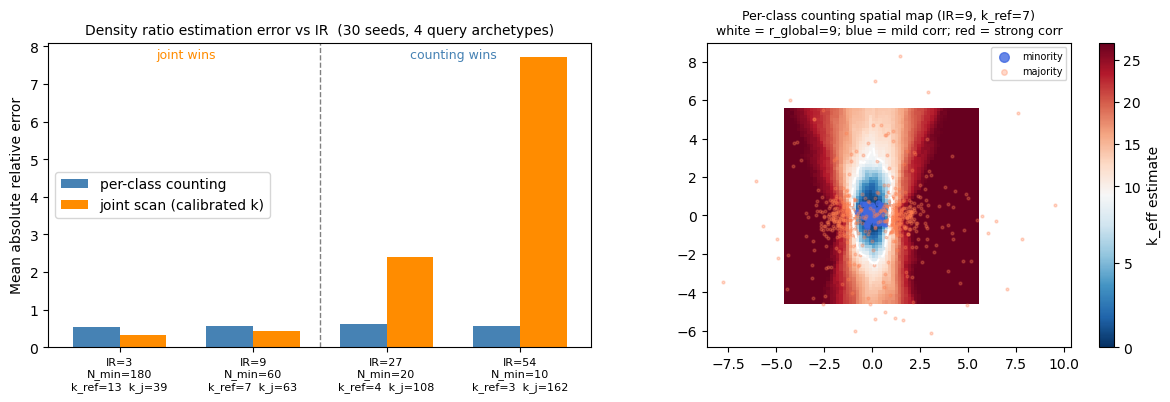

  IR   N_min   k_ref     k_j   counting MAE   joint MAE  winner
-----------------------------------------------------------------
   3     180      13      39          0.546       0.331  joint
   9      60       7      63          0.576       0.443  joint
  27      20       4     108          0.632       2.394  counting
  54      10       3     162          0.572       7.717  counting

Conclusion:
  Joint scan wins when N_min is large (Poisson variance manageable).
  Per-class counting wins at high IR: denominator is guaranteed = k_ref, not random.
  Per-class counting is the safer default for imbalanced benchmarks.

Win over standard FairRank (fixed k_eff = r everywhere):
  Query                   true rho   global r   counting est   error_r   error_c
  -------------------------------------------------------------------------
  minority core               0.10        9.0           0.14     8.904     0.047
  boundary                   14.32        9.0           5.29     0.372     0.631

In [11]:
# SS 20  Joint scan vs per-class counting — IR sensitivity test
# Self-contained.

import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

N_maj_fixed = 540
sigma_min, sigma_blob, sigma_bg = 0.3, 0.6, 3.0
mu_R, mu_L = np.array([1.5, 0.0]), np.array([-1.5, 0.0])
d_eff = 2.0
N_SEEDS = 30

query_points = {
    'minority\ncore':   np.array([0.0, 0.0]),
    'boundary':          np.array([0.8, 0.0]),
    'majority\nblob':   np.array([1.5, 0.0]),
    'background':        np.array([0.0, 3.5]),
}

def true_rho(x, N_min, N_maj):
    rho_min = multivariate_normal.pdf(x, mean=[0,0], cov=sigma_min**2*np.eye(2))
    rho_maj = (multivariate_normal.pdf(x, mean=mu_R, cov=sigma_blob**2*np.eye(2)) +
               multivariate_normal.pdf(x, mean=mu_L, cov=sigma_blob**2*np.eye(2)) +
               multivariate_normal.pdf(x, mean=[0,0], cov=sigma_bg**2*np.eye(2))) / 3.0
    return (rho_maj * N_maj) / max(rho_min * N_min, 1e-300)

def counting_est(x, X_min, X_maj, k_ref):
    d_min = np.sort(np.linalg.norm(X_min - x, axis=1))
    if k_ref > len(d_min): return np.nan
    return float(np.sum(np.linalg.norm(X_maj - x, axis=1) <= d_min[k_ref-1])) / k_ref

def joint_est(x, X_train, y_train, k):
    dists = np.linalg.norm(X_train - x, axis=1)
    k = min(k, len(dists))
    labels_k = y_train[np.argpartition(dists, k-1)[:k]]
    n_min = int(np.sum(labels_k == 0))
    return float(np.sum(labels_k == 1)) / n_min if n_min > 0 else np.inf

# ── IR sweep ─────────────────────────────────────────────────────────────────
ir_values = [3, 9, 27, 54]
mae_counting = []
mae_joint    = []
k_refs_used  = []
k_js_used    = []

for ir in ir_values:
    N_min_t = N_maj_fixed // ir
    r_global = N_maj_fixed / N_min_t
    k_ref = max(3, int(N_min_t ** 0.5))
    # Calibrated joint k: expected to contain k_ref minority on average
    k_j = int(r_global * k_ref)
    k_refs_used.append(k_ref)
    k_js_used.append(k_j)

    errs_c, errs_j = [], []
    for seed in range(N_SEEDS):
        rng = np.random.RandomState(seed)
        X_min = rng.randn(N_min_t, 2) * sigma_min
        X_maj = np.vstack([rng.randn(N_maj_fixed//3,2)*sigma_blob+mu_R,
                           rng.randn(N_maj_fixed//3,2)*sigma_blob+mu_L,
                           rng.randn(N_maj_fixed-2*(N_maj_fixed//3),2)*sigma_bg])
        X_tr = np.vstack([X_min, X_maj])
        y_tr = np.array([0]*N_min_t + [1]*N_maj_fixed)
        for x in query_points.values():
            truth = true_rho(x, N_min_t, N_maj_fixed)
            if not (np.isfinite(truth) and truth < 1e6): continue
            c = counting_est(x, X_min, X_maj, k_ref)
            j = joint_est(x, X_tr, y_tr, k_j)
            if np.isfinite(c):
                errs_c.append(abs(c - truth) / max(truth, 1.0))
            if np.isfinite(j):
                errs_j.append(abs(j - truth) / max(truth, 1.0))
    mae_counting.append(float(np.mean(errs_c)))
    mae_joint.append(float(np.mean(errs_j)))

# ── Plot 1: MAE vs IR ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x_pos = np.arange(len(ir_values))
w = 0.35
bars_c = ax.bar(x_pos - w/2, mae_counting, w, label='per-class counting', color='steelblue')
bars_j = ax.bar(x_pos + w/2, mae_joint,    w, label='joint scan (calibrated k)', color='darkorange')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'IR={ir}\nN_min={N_maj_fixed//ir}\nk_ref={kr}  k_j={kj}'
                    for ir, kr, kj in zip(ir_values, k_refs_used, k_js_used)], fontsize=8)
ax.set_ylabel('Mean absolute relative error')
ax.set_title('Density ratio estimation error vs IR  (30 seeds, 4 query archetypes)', fontsize=10)
ax.legend()
ax.axvline(1.5, color='gray', ls='--', lw=1)
ax.text(0.5, ax.get_ylim()[1]*0.95, 'joint wins', ha='center', fontsize=9, color='darkorange')
ax.text(2.5, ax.get_ylim()[1]*0.95, 'counting wins', ha='center', fontsize=9, color='steelblue')

# ── Plot 2: spatial heatmap of counting estimate at IR=9 ─────────────────────
ax = axes[1]
N_min_demo = N_maj_fixed // 9
rng = np.random.RandomState(0)
X_min_d = rng.randn(N_min_demo, 2) * sigma_min
X_maj_d = np.vstack([rng.randn(N_maj_fixed//3,2)*sigma_blob+mu_R,
                     rng.randn(N_maj_fixed//3,2)*sigma_blob+mu_L,
                     rng.randn(N_maj_fixed-2*(N_maj_fixed//3),2)*sigma_bg])
k_ref_d = max(3, int(N_min_demo**0.5))
r_global_d = N_maj_fixed / N_min_demo

res = 60
g = np.linspace(-4.5, 5.5, res)
GX, GY = np.meshgrid(g, g)
grid = np.column_stack([GX.ravel(), GY.ravel()])
Z = np.array([counting_est(pt, X_min_d, X_maj_d, k_ref_d) for pt in grid]).reshape(res, res)
Z_clipped = np.clip(Z, 0, 3*r_global_d)

import matplotlib.colors as mcolors
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=r_global_d, vmax=3*r_global_d)
im = ax.pcolormesh(GX, GY, Z_clipped, norm=norm, cmap='RdBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='k_eff estimate')
ax.scatter(X_min_d[:,0], X_min_d[:,1], c='royalblue', s=12, alpha=0.8, label='minority')
ax.scatter(X_maj_d[:,0], X_maj_d[:,1], c='coral', s=4, alpha=0.3, label='majority')
ax.contour(GX, GY, Z, levels=[r_global_d], colors='white', linewidths=1.5, linestyles='--')
ax.set_aspect('equal')
ax.set_title(f'Per-class counting spatial map (IR={9}, k_ref={k_ref_d})\n'
             f'white = r_global={r_global_d:.0f}; blue = mild corr; red = strong corr', fontsize=9)
ax.legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print(f'{"IR":>4}  {"N_min":>6}  {"k_ref":>6}  {"k_j":>6}  {"counting MAE":>13}  {"joint MAE":>10}  winner')
print('-' * 65)
for ir, kr, kj, mc, mj in zip(ir_values, k_refs_used, k_js_used, mae_counting, mae_joint):
    winner = 'joint' if mj < mc else 'counting'
    print(f'{ir:>4}  {N_maj_fixed//ir:>6}  {kr:>6}  {kj:>6}  {mc:>13.3f}  {mj:>10.3f}  {winner}')

print()
print('Conclusion:')
print('  Joint scan wins when N_min is large (Poisson variance manageable).')
print('  Per-class counting wins at high IR: denominator is guaranteed = k_ref, not random.')
print('  Per-class counting is the safer default for imbalanced benchmarks.')
print()
print('Win over standard FairRank (fixed k_eff = r everywhere):')
rng2 = np.random.RandomState(0)
X_min_f = rng2.randn(N_min_demo, 2) * sigma_min
X_maj_f = np.vstack([rng2.randn(N_maj_fixed//3,2)*sigma_blob+mu_R,
                     rng2.randn(N_maj_fixed//3,2)*sigma_blob+mu_L,
                     rng2.randn(N_maj_fixed-2*(N_maj_fixed//3),2)*sigma_bg])
print(f'  {"Query":<20}  {"true rho":>10}  {"global r":>9}  {"counting est":>13}  {"error_r":>8}  {"error_c":>8}')
print('  ' + '-'*73)
for label, x in query_points.items():
    truth = true_rho(x, N_min_demo, N_maj_fixed)
    c = counting_est(x, X_min_f, X_maj_f, k_ref_d)
    tag = label.replace('\n', ' ')
    if np.isfinite(truth) and truth < 1e6 and np.isfinite(c):
        err_r = abs(r_global_d - truth) / max(truth, 1)
        err_c = abs(c - truth) / max(truth, 1)
        print(f'  {tag:<20}  {truth:>10.2f}  {r_global_d:>9.1f}  {c:>13.2f}  {err_r:>8.3f}  {err_c:>8.3f}')


# 21. Adaptive Rank Correction via Bayesian $\alpha$-Shrinkage

### 21.1 The Objective
While `KNNFairRankJointCV` finds the optimal global exponent $\alpha_{\text{CV}}$, it remains a "high-bias" estimator because it assumes the class imbalance $r$ behaves identically across the entire feature space. We aim to refine this by allowing the correction to adapt to local density shifts, using the **stable per-class counting** method from Section 20, without losing the stability of the global cross-validated baseline.

### 21.2 Mathematical Deduction

**1. The Global Baseline (Prior Knowledge):**
The standard FairRank correction uses a global imbalance ratio $r = N_{\text{maj}} / N_{\text{min}}$ modulated by an exponent $\alpha$:
$$k_{\text{eff, global}} = r^{\alpha_{\text{CV}}}$$

**2. The Local Density Signal (Evidence):**
From Section 20, we have the stable per-class counting estimator $\hat{\rho}(x)$. Given a query point $x$ and a minority budget $k_{\text{ref}}$, the local class odds are:
$$\hat{\rho}(x) = \frac{\#\{\text{maj in } \text{ball}(x, d_{k_{\text{ref}}}^{\text{min}}(x))\}}{k_{\text{ref}}}$$

**3. Mapping to Alpha-Space:**
To make the local signal compatible with our global parameter $\alpha_{\text{CV}}$, we solve for the local exponent $\alpha_{\text{local}}(x)$ that would satisfy $r^{\alpha_{\text{local}}(x)} = \hat{\rho}(x)$:
$$\alpha_{\text{local}}(x) \cdot \log(r) = \log(\hat{\rho}(x)) \implies \alpha_{\text{local}}(x) = \frac{\log(\hat{\rho}(x))}{\log(r)}$$

**4. The Bayesian Shrinkage Model:**
To prevent overfitting to local noise (the "replacement" failure), we apply a credibility weight $w \in [0, 1]$ to the global prior. The final combined exponent is:
$$\alpha_{\text{final}}(x) = w \cdot \alpha_{\text{CV}} + (1 - w) \cdot \alpha_{\text{local}}(x)$$

**5. Final Decision Rule:**
The query-specific fair rank comparison is then:
$$\boxed{k_{\text{eff}}(x) = \text{round} \left( r^{\alpha_{\text{final}}(x)} \right)}$$

---

### 21.3 Why This Works: The Bias-Variance Synthesis



* **Section 20 Robustness:** By using the counting estimator $\hat{\rho}(x)$ (fixing the minority denominator), we avoid the high-variance Poisson noise typical of distance-ratio or joint-scan methods.
* **The Logarithmic Normalizer:** Dividing by $\log(r)$ ensures that $\alpha_{\text{local}}(x)$ is centered around $1.0$ when local density matches the global mean. This allows the correction to stay within the logical bounds explored during our CV grid search.
* **Global Anchoring:** The weight $w$ acts as a regularizer. In regions of high uncertainty or low sample size, the model "shrinks" back toward $\alpha_{\text{CV}}$. The correction only deviates when the local density provides a strong, stable signal that a different rank comparison is necessary.



This approach effectively transforms the static "calibration" of FairRank into a **spatially-aware, dynamic correction**, improving precision at the decision boundary where global averages are most likely to fail.

---

## 22. KNNFairRankTopoCount — Joint-Scale Topology with Per-Class Counting

### 22.1 The Full Chain of Reasoning

This section documents the algorithm that emerged from the following sequence of questions.

**Q1. Why does the base FairRank use $k_{\text{eff}} = r$?**

It derives from setting $\mathbb{E}[d^{\text{maj}}_{k_{\text{eff}}} \mid x] = \mathbb{E}[d^{\text{min}}_1 \mid x]$ under a Poisson-uniform spatial process for each class:

$$\mathbb{E}[d^c_k \mid x] \;\propto\; \left(\frac{k}{N_c \cdot f_c(x)}\right)^{1/d}$$

Setting equal and raising both sides to the power $d$ (a monotone transformation — equality is preserved regardless of $d$):

$$\frac{k_{\text{eff}}}{N_{\text{maj}} \cdot f_{\text{maj}}(x)} = \frac{1}{N_{\text{min}} \cdot f_{\text{min}}(x)}
\quad\Longrightarrow\quad
\boxed{k_{\text{eff}}(x) = \frac{N_{\text{maj}} \cdot f_{\text{maj}}(x)}{N_{\text{min}} \cdot f_{\text{min}}(x)}}$$

Here $f_c(x) = p(x \mid Y = c)$ is the **class-conditional** spatial density. Under globally uniform density $f_{\text{maj}} = f_{\text{min}}$ and we recover $k_{\text{eff}} = r$.

---

**Q2. What does the $\alpha$ exponent actually correct?**

The CV-selected $\alpha$ in `KNNFairRankCV` produces $k_{\text{eff}} = r^\alpha$. Substituting into the general formula:

$$r^\alpha = r \cdot r^{\alpha - 1} = r \cdot \frac{f_{\text{maj}}(x)}{f_{\text{min}}(x)}
\quad\Longrightarrow\quad
\frac{f_{\text{maj}}}{f_{\text{min}}} \approx r^{\alpha - 1}$$

$\alpha$ is approximating the **ratio of class-conditional densities** as a single global constant $r^{\alpha-1}$. When $\alpha < 1$, minority is locally denser than the uniform assumption predicts. CV finds the $\alpha$ that best approximates this global average — correct direction, but a single scalar cannot represent spatial variation.

---

**Q3. What does `KNNFairRankLocalCount` (§20) actually compute?**

For query $x$, define a ball of radius $r = d^{\text{min}}_{k_{\text{ref}}}(x)$ — the distance to the $k_{\text{ref}}$-th nearest minority training point. Count both classes in that ball:

$$n_{\text{min, ball}} = k_{\text{ref}} \quad \text{(by construction)}$$
$$n_{\text{maj, ball}} = \#\{\text{maj within radius } r\}$$

Estimate each class-conditional density using Poisson counting:

$$f_c(x) \approx \frac{n_{c,\text{ball}}}{N_c \cdot \omega_d \cdot r^d}$$

Plug into the exact formula:

$$k_{\text{eff}}(x) = \frac{N_{\text{maj}} \cdot f_{\text{maj}}}{N_{\text{min}} \cdot f_{\text{min}}}
= \frac{n_{\text{maj, ball}} \;/\; (N_{\text{maj}} \cdot \omega_d r^d)}{n_{\text{min, ball}} \;/\; (N_{\text{min}} \cdot \omega_d r^d)}
= \frac{n_{\text{maj, ball}}}{n_{\text{min, ball}}}
= \frac{n_{\text{maj, ball}}}{k_{\text{ref}}}$$

**The key**: $\omega_d \cdot r^d$ cancels exactly because both classes use the **same ball** (same centre $x$, same radius $r$). The dimension $d$ never appears. This is not an approximation — it is an exact algebraic cancellation.

---

**Q4. What is wrong with fixing $k_{\text{ref}}$?**

$r = d^{\text{min}}_{k_{\text{ref}}}(x)$ anchors the ball to the minority distribution. The scale adapts with minority density:

- **Minority-dense region**: $r$ is small → tight ball → accurate local estimate.
- **Minority-sparse region**: $k_{\text{ref}}$-th minority neighbour is far away → $r$ is large → ball spans heterogeneous majority territory → heavily biased estimate.

Exactly the regions where correction matters most (sparse minority, high imbalance) have the worst density estimates. $k_{\text{ref}}$ is arbitrary and has no connection to the natural scale of the data.

---

### 22.2 What Topology Adds: A Principled Scale

Persistent homology on the **joint** point cloud gives a data-driven radius $\varepsilon^*(x)$ for each query point $x$.

**Intuition — the Vietoris-Rips filtration**: start from all $N$ training points as isolated nodes. Grow balls of radius $\varepsilon$ around every point simultaneously. When two balls overlap, their points merge into one connected component. As $\varepsilon$ increases, components merge until everything is one piece.

For query $x$, track when its component first **merges with a neighbouring component**. Call that distance $\varepsilon^*(x)$.

- **Below $\varepsilon^*(x)$**: $x$'s neighbourhood is not yet coherent — density estimate is unstable (sampling from an incomplete local structure).
- **Above $\varepsilon^*(x)$**: $x$'s local piece has blended with a structurally separate region — density estimate is biased (mixing regimes).
- **At $\varepsilon^*(x)$**: the ball is exactly the coherent local neighbourhood of $x$ — the right scale for density estimation.

This is the **persistence** of $x$'s H0 component in the joint filtration. The larger the gap between $\varepsilon^*(x)$ and the next merge, the more reliable the density estimate at that scale.

---

### 22.3 The "Two Regions" Question

Minority and majority may have very different natural clustering scales at $x$. Can we run separate PH per class and use each class's own scale?

If we use different radii $r_{\text{min}} \neq r_{\text{maj}}$:

$$k_{\text{eff}} = \frac{n_{\text{maj in ball}(r_{\text{maj}})}}{n_{\text{min in ball}(r_{\text{min}})}}
= \frac{N_{\text{maj}} \cdot f_{\text{maj}} \cdot \omega_d r_{\text{maj}}^d}{N_{\text{min}} \cdot f_{\text{min}} \cdot \omega_d r_{\text{min}}^d}
= k_{\text{eff, exact}} \cdot \left(\frac{r_{\text{maj}}}{r_{\text{min}}}\right)^d$$

**Dimension $d$ reappears**. The cancellation only holds when both classes use the same ball.

**Resolution**: use a single $\varepsilon^*$ from the **joint** PH. At that shared scale, each class has its own count inside the ball — you get separate regions per class — but because the radius is the same, $\omega_d \varepsilon^{*d}$ still cancels.

You get the best of both: separate per-class structure is captured by the counts $n_{\text{min}}$ and $n_{\text{maj}}$ within the ball, while dimension-freedom is preserved by the shared scale.

---

### 22.4 The Complete Algorithm

#### Fit time

1. Fit the base `KNNFairRank` (computes $N_{\text{min}}$, $N_{\text{maj}}$, $r$, per-class neighbour lists). No change.
2. Determine a global maximum neighbourhood size $k_{\text{max}}$ (e.g. $\lfloor\sqrt{N}\rfloor$) used to bound per-query PH cost.

No topology is run at fit time.

#### Inference for query $x$

**Step 1 — Fetch per-class sorted distances.**  
Already computed by `_per_class_distances(x)`: sorted arrays $d_{\text{min}}$ and $d_{\text{maj}}$.

**Step 2 — Build the joint local neighbourhood.**  
Take the $k_{\text{max}}$ nearest training points regardless of class. These are the first $k_{\text{max}}$ entries of the combined sorted distance list.

**Step 3 — Run PH on the local neighbourhood.**  
Apply Vietoris-Rips persistent homology (H0 only, using `ripser`) to the $k_{\text{max}}$ neighbourhood point cloud. Extract the H0 persistence diagram.

**Step 4 — Select $\varepsilon^*(x)$.**  
From the finite H0 bars (all bars except the one that never dies), find the **most persistent bar** — the one whose death time is most separated from the next bar. Its death time is $\varepsilon^*(x)$.

Alternatively: find the largest gap in the sequence of H0 death times restricted to structurally meaningful merges (analogous to the Ward gap used in `KNNFairRankTopoJoint`).

If no bar has sufficient persistence (the neighbourhood is already homogeneous), fall back to the LocalCount formula with the default $k_{\text{ref}}$.

**Step 5 — Count both classes at the topology-derived scale.**  
Using the already-sorted $d_{\text{min}}$ and $d_{\text{maj}}$:

```python
n_min_ball = np.searchsorted(d_min, eps_star, side='right')
n_maj_ball = np.searchsorted(d_maj, eps_star, side='right')
k_eff = max(1, round(n_maj_ball / max(1, n_min_ball)))
```

This is one binary search per class — $O(\log N_c)$ — after the PH step.

**Step 6 — Standard FairRank voting with $k_{\text{eff}}(x)$.**  
Identical to all other FairRank variants.

---

### 22.5 Degenerate Cases and the $k_{\text{max}}$ Invariant

#### The last degenerate case is provably impossible with the right design

The final degenerate case in a naive implementation is $\varepsilon^*(x) > \max(d_{\text{min}})$ — the topology-derived scale is larger than the furthest minority point fetched, so the count is truncated.

The fix is not a fallback. It is a single invariant that eliminates the case entirely.

**Proof that the case cannot occur:**

$\varepsilon^*(x)$ is derived from the PH of the $k_{\text{max}}$ joint neighbours. All H0 merge distances in that filtration are bounded by the diameter of the pool, so:

$$\varepsilon^*(x) \;\leq\; d^{\text{joint}}_{k_{\text{max}}}(x)$$

The joint neighbourhood at any rank $k$ is a superset of the class-specific neighbourhood, so it can only be closer:

$$d^{\text{joint}}_k(x) \;\leq\; d^{\text{min}}_k(x)$$

Chaining the two:

$$\varepsilon^*(x) \;\leq\; d^{\text{joint}}_{k_{\text{max}}}(x) \;\leq\; d^{\text{min}}_{k_{\text{max}}}(x)$$

Therefore: if $k_{\text{min\_eff}} \geq k_{\text{max}}$, then $d_{\text{min}}[k_{\text{min\_eff}} - 1] \geq d^{\text{min}}_{k_{\text{max}}}(x) \geq \varepsilon^*(x)$ and the case is impossible. The same argument holds for majority.

**The invariant:**

$$\boxed{k_{\text{min\_eff}} = k_{\text{maj\_eff}} = k_{\text{max}}}$$

Set this once at fit time. All three neighbourhood sizes collapse to one design parameter. No per-query extension, no fallback for this case.

#### Remaining degenerate cases (genuinely data-driven)

| Condition | Cause | Response |
|-----------|-------|----------|
| $n_{\text{min, ball}} = 0$ | No minority near $x$ at $\varepsilon^*$ — x is in a pure-majority region | Fall back to global $r$ (cap $k_{\text{eff}}$ at $r$) |
| $n_{\text{maj, ball}} = 0$ | No majority near $x$ at $\varepsilon^*$ — x is in a pure-minority region | $k_{\text{eff}} = 0$ → predict minority directly |
| No persistent H0 gap found | Joint neighbourhood is already homogeneous at $x$ | Fall back to LocalCount with default $k_{\text{ref}}$ |

These three cases reflect genuine data geometry and cannot be designed away. They each have a principled response.

---

### 22.6 Why This Is Better Than Existing Variants

| Variant | How $k_{\text{eff}}$ is set | Problem |
|---------|----------------------------|---------|
| `KNNFairRank` | $r$ (global) | Wrong locally |
| `KNNFairRankCV` | $r^\alpha$ (global + CV) | One scalar for whole dataset |
| `KNNFairRankLocalCount` | Counting at fixed $k_{\text{ref}}$ | Scale anchored to minority, $k_{\text{ref}}$ arbitrary |
| `KNNFairRankTopoJoint` | Local count in Ward region | Ward $\neq$ PH; regions global (not per-query) |
| **`KNNFairRankTopoCount`** | **Counting at topology-derived $\varepsilon^*(x)$, $k_{\text{max}}$ invariant** | **Adaptive scale; dimension-free; no degenerate boundary** |

---

### 22.7 Complexity

| Phase | Cost |
|-------|------|
| Fit | $O(N \log N)$ — same as base KNNFairRank |
| Inference per query (PH) | $O(k_{\text{max}}^2 \log k_{\text{max}})$ — ripser on $k_{\text{max}}$ points |
| Inference per query (counting) | $O(\log k_{\text{max}})$ — binary search in sorted distances (bounded by $k_{\text{max}}$, not $N_c$) |
| Inference per query (voting) | $O(n_{\text{votes}})$ — same as all variants |

The PH step dominates. For $k_{\text{max}} = \lfloor\sqrt{N}\rfloor$ this is $O(N \log N)$ per query, which is expensive for large datasets. In practice $k_{\text{max}} \leq 50$ is sufficient for most benchmark datasets, making the PH cost negligible.

The natural choice for $k_{\text{max}}$ is:

$$k_{\text{max}} = \max\!\left(\lfloor\sqrt{N}\rfloor,\; r \cdot k_{\text{ref}}\right)
\quad\text{where}\quad k_{\text{ref}} = \lfloor\sqrt{N_{\text{min}}}\rfloor$$

This ensures the joint pool contains roughly $k_{\text{ref}}$ minority points in expectation (sufficient for reliable PH), and matches the scale at which the counting formula is most stable.
